# GATV2

What I still need to do: work with graphs that don't have self loops

In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import os
import sys

from tests import *

from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.epidataloader import EpiDataLoader
from src.models.gatv2_paper import PaperGRU_GATv2_Model_Wrapper

n_periods = 8
n_epochs  = 250
horizon   = 1
lags      = range(2,3)


epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2025-06-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(lags = lags)

if 'population_size' in epidata.feature_columns:
    epidata.feature_columns.remove('population_size')

gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
lr = 0.0005/10

# ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader1)
# ml.set_model_hparams()
# ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
# ml.train(show_loss = False)
# ml.forecast()
# ml.forecast()
# ml.show_forecasts(norm=True)
# validator = GraphUsageValidator(ml)
# # validator.run_tests()
# validator.test1()
# print(validator.logs)

ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':15, 'gamma':0.8}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts()
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

# ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader3)
# ml.set_model_hparams()
# ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
# ml.train(show_loss = False)
# ml.forecast()
# ml.forecast()
# ml.show_forecasts(norm=True)
# validator = GraphUsageValidator(ml)
# # validator.run_tests()
# validator.test1()
# print(validator.logs)

Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 0.9228, val loss: 1.7651 ✓ (new best)
Epoch 2 train loss: 0.8964, val loss: 1.6877 ✓ (new best)
Epoch 3 train loss: 0.8735, val loss: 1.6131 ✓ (new best)
Epoch 4 train loss: 0.8472, val loss: 1.5224 ✓ (new best)
Epoch 5 train loss: 0.8146, val loss: 1.4074 ✓ (new best)
Epoch 6 train loss: 0.7781, val loss: 1.2841 ✓ (new best)
Epoch 7 train loss: 0.7462, val loss: 1.1811 ✓ (new best)
Epoch 8 train loss: 0.7248, val loss: 1.1089 ✓ (new best)
Epoch 9 train loss: 0.7121, val loss: 1.0614 ✓ (new best)
Epoch 10 train loss: 0.7021, val loss: 1.0278 ✓ (new best)
Epoch 11 train loss: 0.6950, val loss: 1.0015 ✓ (new best)
Epoch 12 train loss: 0.6885, val loss: 0.9791 ✓ (new best)
Epoch 13 train loss: 0.6838, val loss: 0.9603 ✓ (new best)
Epoch 14 train loss: 0.6804, val loss: 0.9426 ✓ (new best)
Epoch 15 train loss: 0.6736, val loss: 0.9354 ✓ (new best)
Epoch 16 train loss: 0.6665, 

TypeError: ModelCore.show_forecasts() got an unexpected keyword argument 'norm'

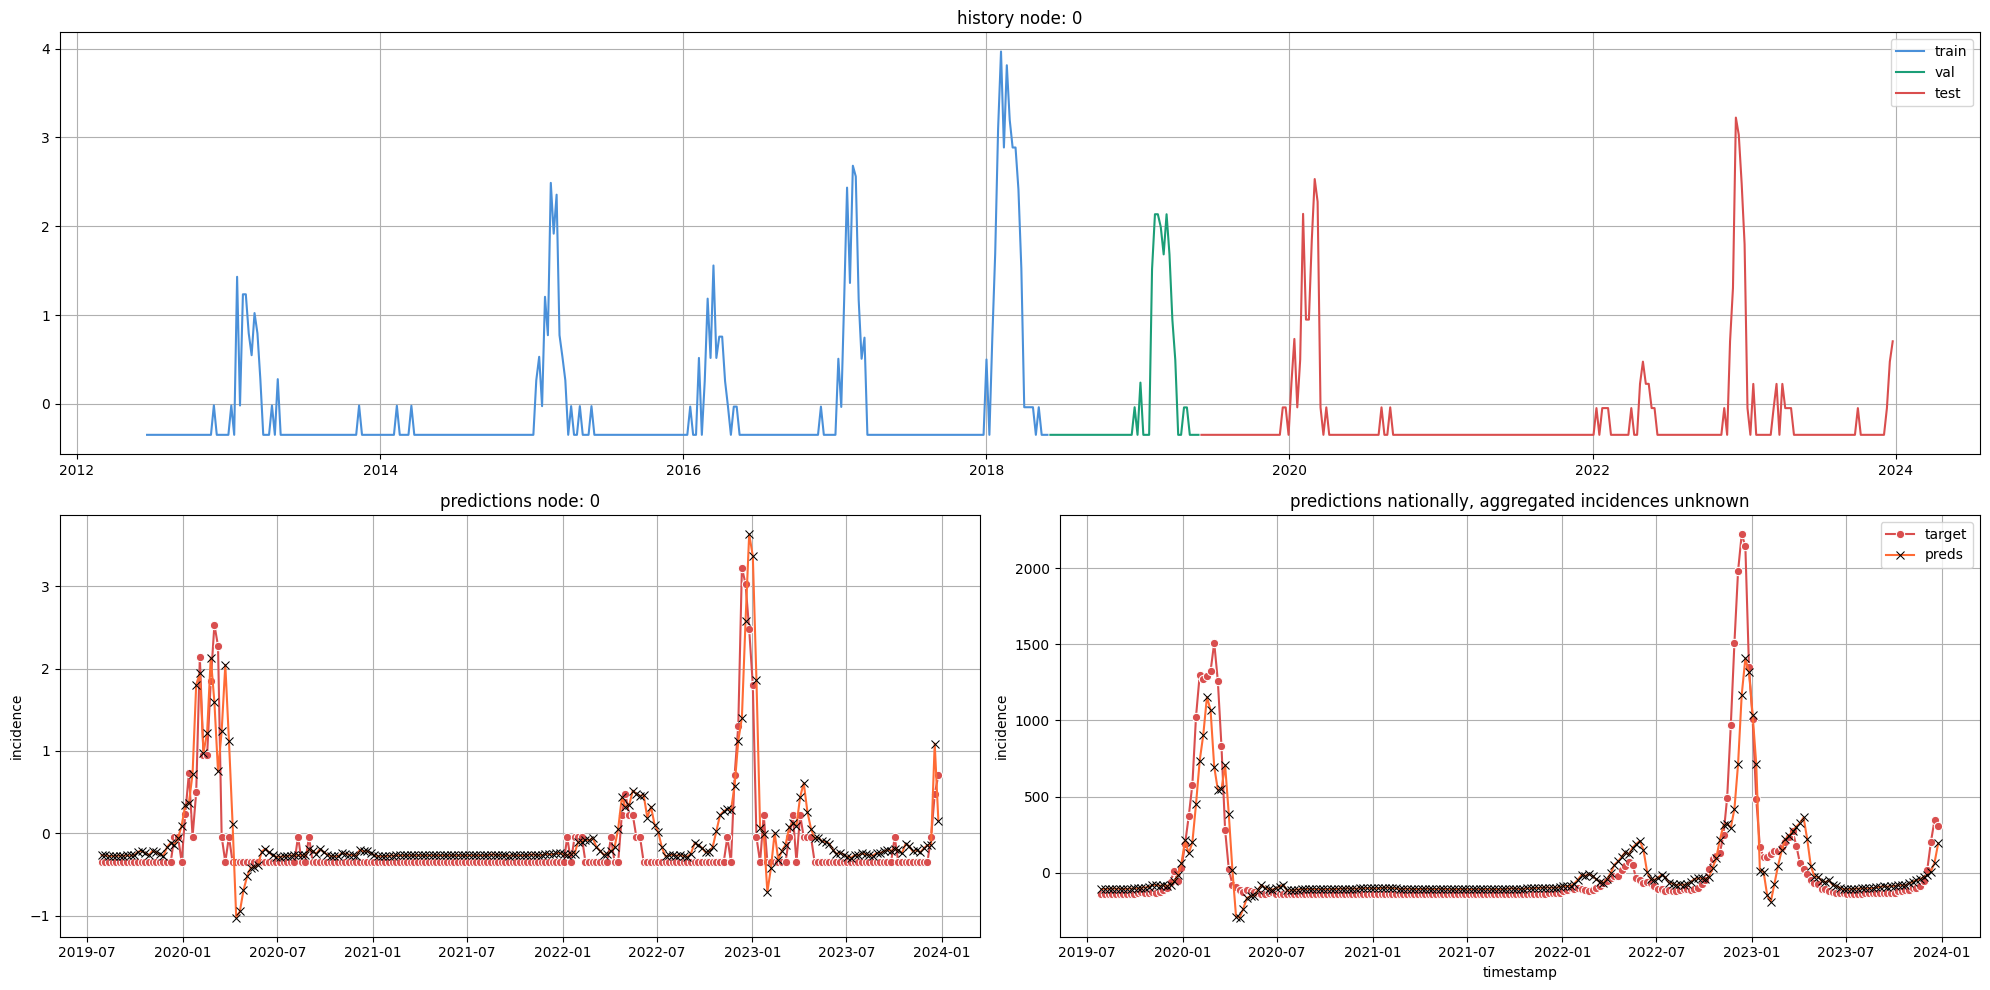

In [6]:
ml.show_forecasts()

In [7]:
ml.evaluation_df

,timestamp,population_size,incidence,node,incidence_lag2,timestamp_idx,preds
0,2019-07-29,0.385079,-0.239910,204,-0.349231,0,-0.248865
1,2019-08-05,0.385079,-0.349231,204,-0.349231,1,-0.256556
2,2019-08-12,0.385079,-0.134513,204,-0.239910,2,-0.263799
3,2019-08-19,0.385079,-0.349231,204,-0.349231,3,-0.233136
4,2019-08-26,0.385079,-0.349231,204,-0.134513,4,-0.232385
...,...,...,...,...,...,...,...
94936,2023-11-27,-0.694184,-0.349231,404,0.285370,226,0.080914
94937,2023-12-04,-0.694184,-0.349231,404,-0.349231,227,0.165140
94938,2023-12-11,-0.694184,1.036578,404,-0.349231,228,0.177933
94939,2023-12-18,-0.694184,2.420186,404,-0.349231,229,0.569239


In [10]:
epidata.context_data

,kz_03,geometry,week,cases,year,timestamp,population_size
0,01001,"POLYGON ((1047812.976 7327520.138, 1047870.613...",1,0.0,2005,2005-01-03,86080.000000
1,01001,"POLYGON ((1047812.976 7327520.138, 1047870.613...",2,0.0,2005,2005-01-10,86080.000000
2,01001,"POLYGON ((1047812.976 7327520.138, 1047870.613...",3,0.0,2005,2005-01-17,86080.000000
3,01001,"POLYGON ((1047812.976 7327520.138, 1047870.613...",4,1.0,2005,2005-01-24,86080.000000
4,01001,"POLYGON ((1047812.976 7327520.138, 1047870.613...",5,0.0,2005,2005-01-31,86080.000000
...,...,...,...,...,...,...,...
407296,11007,"POLYGON ((1490299.18 6870363.617, 1490295.264 ...",48,3.0,2023,2023-11-27,346430.795805
407297,11007,"POLYGON ((1490299.18 6870363.617, 1490295.264 ...",49,10.0,2023,2023-12-04,346430.795805
407298,11007,"POLYGON ((1490299.18 6870363.617, 1490295.264 ...",50,26.0,2023,2023-12-11,346430.795805
407299,11007,"POLYGON ((1490299.18 6870363.617, 1490295.264 ...",51,30.0,2023,2023-12-18,346430.795805


In [11]:
gnnloader2.norm_params

{'method': 'zscore',
 'params': {'population_size': {'mean': np.float64(199124.3559773948),
   'std': np.float64(167437.4308496625)},
  'incidence': {'mean': np.float64(0.11894609795828835),
   'std': np.float64(0.34059384749635946)},
  'preds': {'mean': np.float64(0.11894609795828835),
   'std': np.float64(0.34059384749635946)},
  'incidence_lag2': {'mean': np.float64(0.11894609795828835),
   'std': np.float64(0.34059384749635946)}}}

In [12]:
from src.dataloading.normalization import reverse_zscore_scaling, reverse_log

In [30]:
def process_predictions(ml):

    train_normalized = ml.dataloader.XYt_train
    # train_denorm     = reverse_zscore_scaling(train_normalized, params = self.dataloader.norm_params['params'])
    # train_denorm     = reverse_log(train_denorm, self.dataloader.logged_params)

    val_normalized   = ml.dataloader.XYt_val
    # val_denorm       = reverse_zscore_scaling(val_normalized, params = self.dataloader.norm_params['params'])
    # val_denorm       = reverse_log(val_denorm, self.dataloader.logged_params)

    test_normalized  = ml.dataloader.XYt_test
    # test_denorm      = reverse_zscore_scaling(test_normalized, params = self.dataloader.norm_params['params'])
    # test_denorm      = reverse_log(test_denorm, self.dataloader.logged_params)

    preds_normalized = ml.evaluation_df
    # preds_denorm      = reverse_zscore_scaling(preds_normalized, params = self.dataloader.norm_params['params'])
    # preds_denorm      = reverse_log(preds_denorm, self.dataloader.logged_params)

    agg_target = preds_normalized.groupby(ml.temporal_column)[ml.target_column].sum().reset_index()
    agg_preds  = preds_normalized.groupby(ml.temporal_column)['preds'].sum().reset_index()
    aggregated_evaluation_df_norm = pd.merge(agg_target, agg_preds, on=ml.temporal_column)
      
    
    # self.XYt_train_denorm =train_denorm
    # self.XYt_val_denorm   =val_denorm
    # self.XYt_test_denorm  =test_denorm
    # self.preds_denorm     =preds_denorm

    # non-normalized
    train_denormalized = reverse_log(reverse_zscore_scaling(train_normalized, params = ml.dataloader.norm_params['params']), ml.dataloader.logged_params)
    val_denormalized   = reverse_log(reverse_zscore_scaling(val_normalized,   params = ml.dataloader.norm_params['params']), ml.dataloader.logged_params)
    test_denorm        = reverse_log(reverse_zscore_scaling(test_normalized,  params = ml.dataloader.norm_params['params']), ml.dataloader.logged_params)

    preds_denormalized       = reverse_log(reverse_zscore_scaling(ml.evaluation_df, params = ml.dataloader.norm_params['params']), ml.dataloader.logged_params)
    agg_target_denormalized = preds_denormalized.groupby(ml.temporal_column)[ml.target_column].sum().reset_index()
    agg_preds_denormalized  = preds_denormalized.groupby(ml.temporal_column)['preds'].sum().reset_index()
    aggregated_evaluation_df_denormalized = pd.merge(agg_target_denormalized, agg_preds_denormalized, on=ml.temporal_column)  

    return aggregated_evaluation_df_norm,aggregated_evaluation_df_denormalized


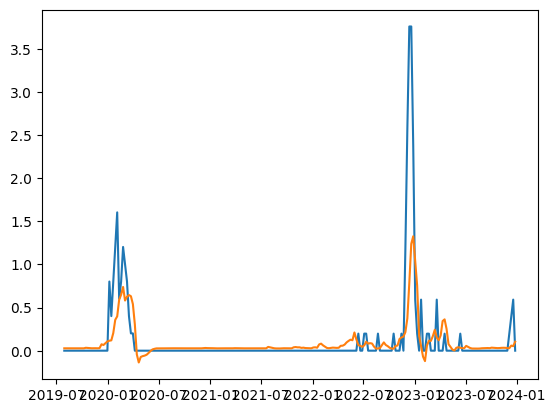

In [35]:

dfs = process_predictions(ml)[0]


plt.plot(df['timestamp'],df['incidence'])
plt.plot(df['timestamp'],df['preds'])


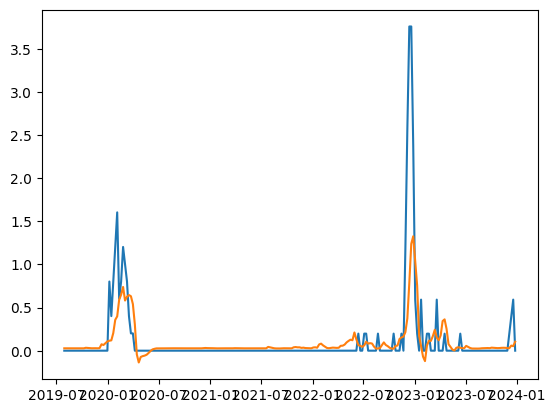

In [36]:
dfs = process_predictions(ml)[1]


plt.plot(df['timestamp'],df['incidence'])
plt.plot(df['timestamp'],df['preds'])

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 411], y=[411, 1], edge_weight=[411])
Epoch 1 train loss: 1.0746, val loss: 2.0265 ✓ (new best)
Epoch 2 train loss: 1.0544, val loss: 1.9730 ✓ (new best)
Epoch 3 train loss: 1.0252, val loss: 1.8689 ✓ (new best)
Epoch 4 train loss: 0.9740, val loss: 1.5654 ✓ (new best)
Epoch 5 train loss: 0.9223, val loss: 1.3880 ✓ (new best)
Epoch 6 train loss: 0.8763, val loss: 1.2371 ✓ (new best)
Epoch 7 train loss: 0.8433, val loss: 1.1305 ✓ (new best)
Epoch 8 train loss: 0.8241, val loss: 1.0649 ✓ (new best)
Epoch 9 train loss: 0.8180, val loss: 1.0136 ✓ (new best)
Epoch 10 train loss: 0.7994, val loss: 0.9569 ✓ (new best)
Epoch 11 train loss: 0.7949, val loss: 0.9477 ✓ (new best)
Epoch 12 train loss: 0.7883, val loss: 0.9391 ✓ (new best)
Epoch 13 train loss: 0.7830, val loss: 0.9287 ✓ (new best)
Epoch 14 train loss: 0.7775, val loss: 0.9204 ✓ (new best)
Epoch 15 train loss: 0.7743, val loss: 0.9150 ✓ (new best)
Epoch 16 train loss: 0.7715, va

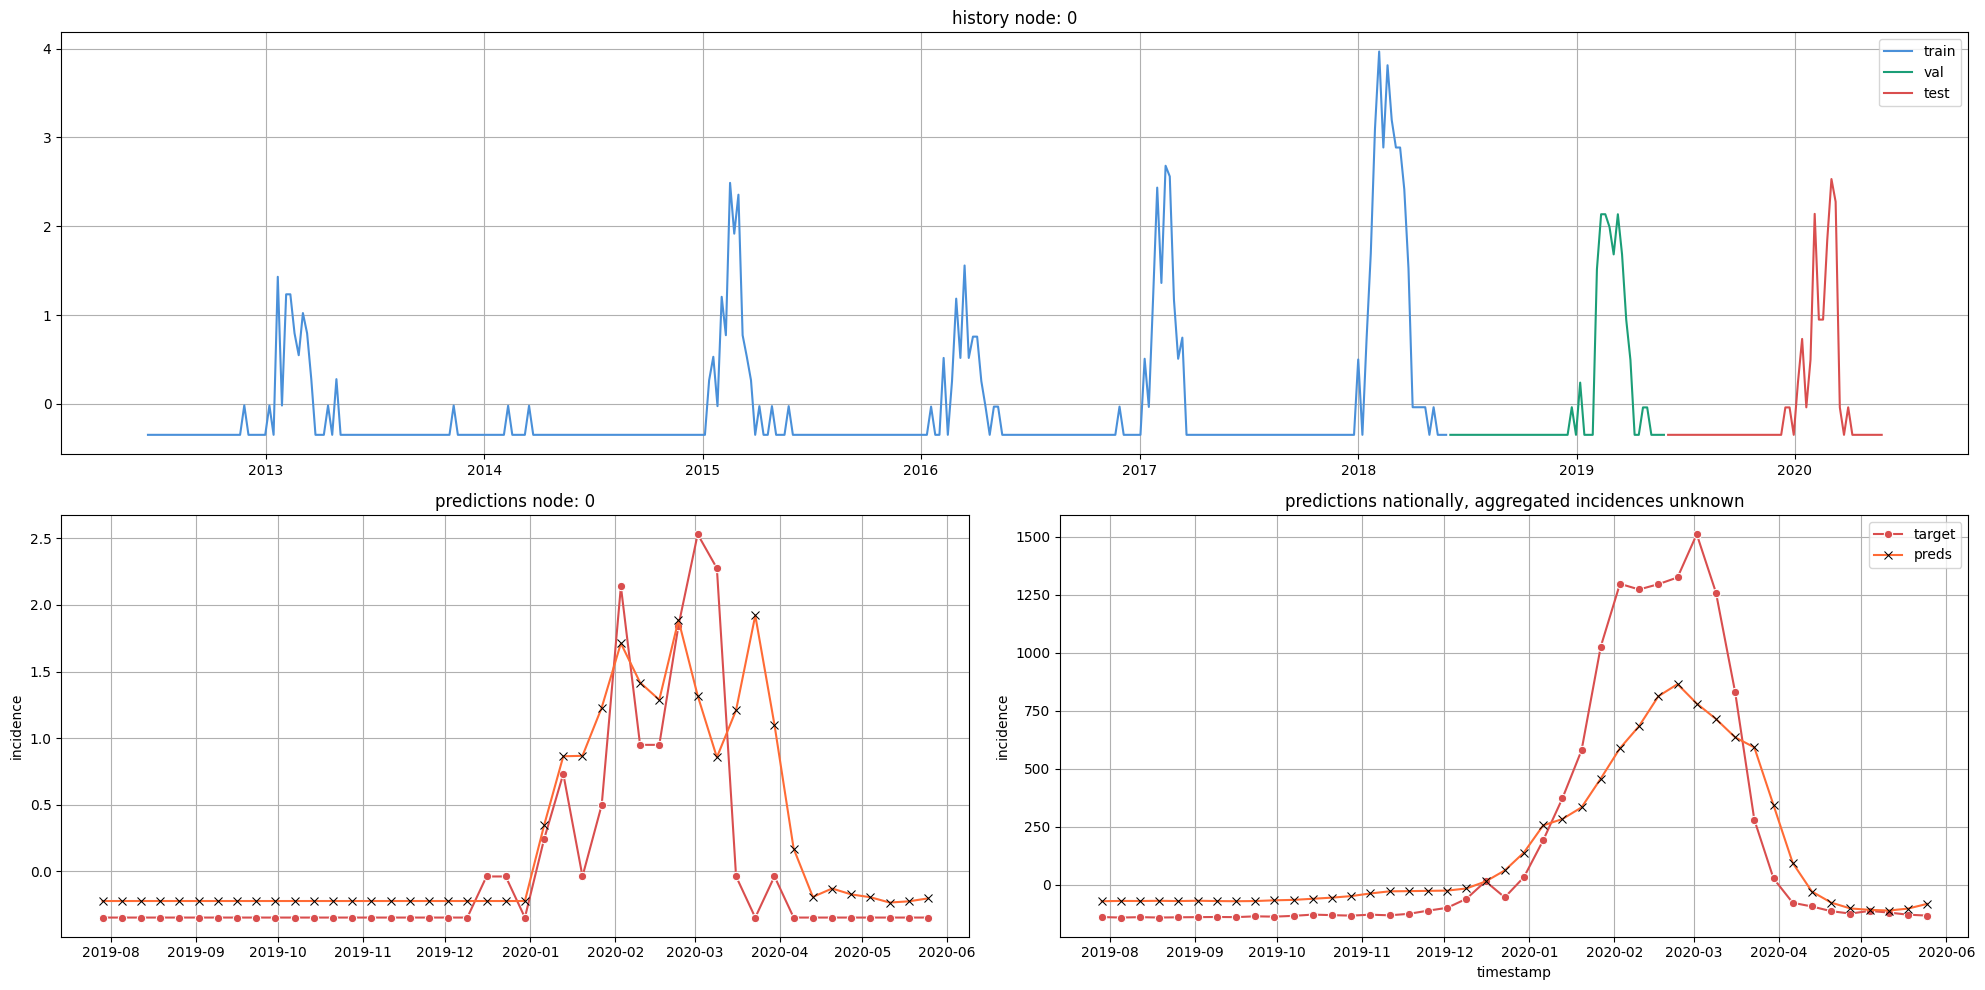

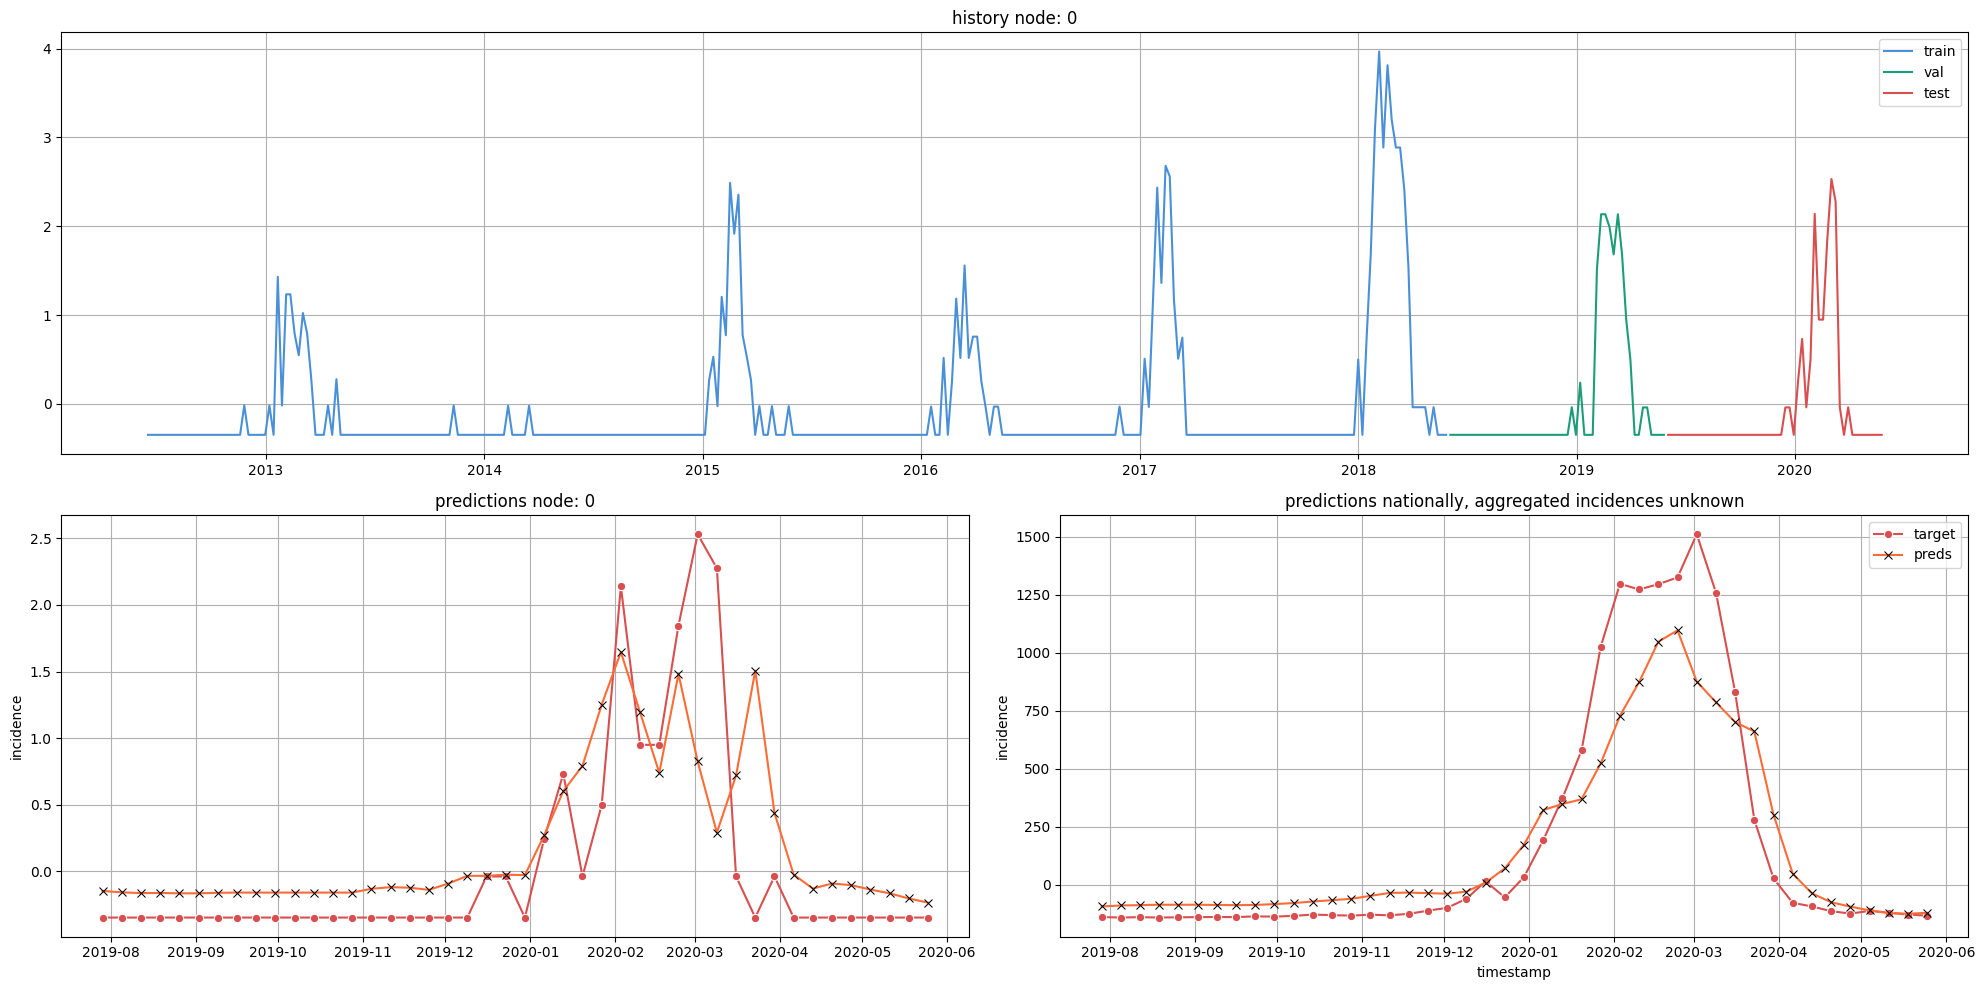

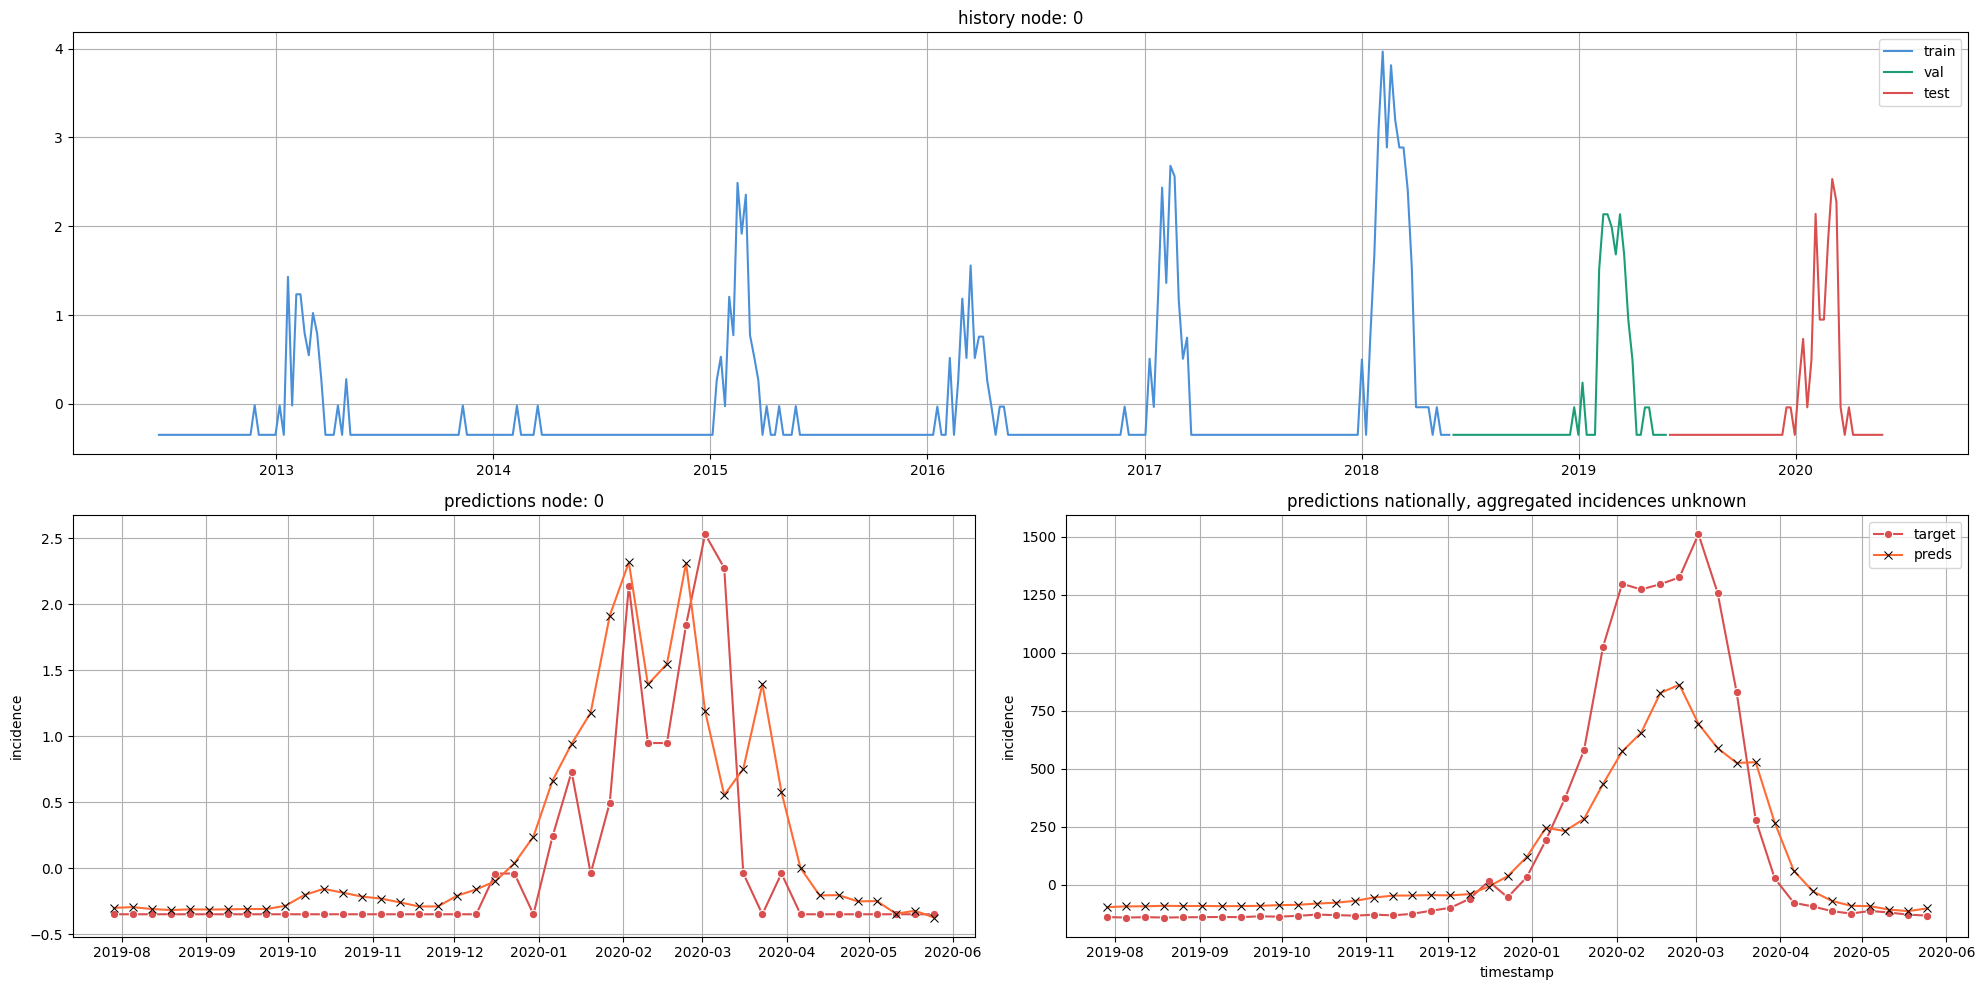

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import os
import sys

from tests import *

from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.epidataloader import EpiDataLoader
from src.models.gatv2 import GRU_GATv2_Model_Wrapper

n_periods = 8
n_epochs  = 250
horizon   = 1
lags      = range(2,3)


epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(lags = lags)

if 'population_size' in epidata.feature_columns:
    epidata.feature_columns.remove('population_size')

gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
# gnnloader1.preview_dataloader(1, timepoint = 10)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)


ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader1)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader3)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

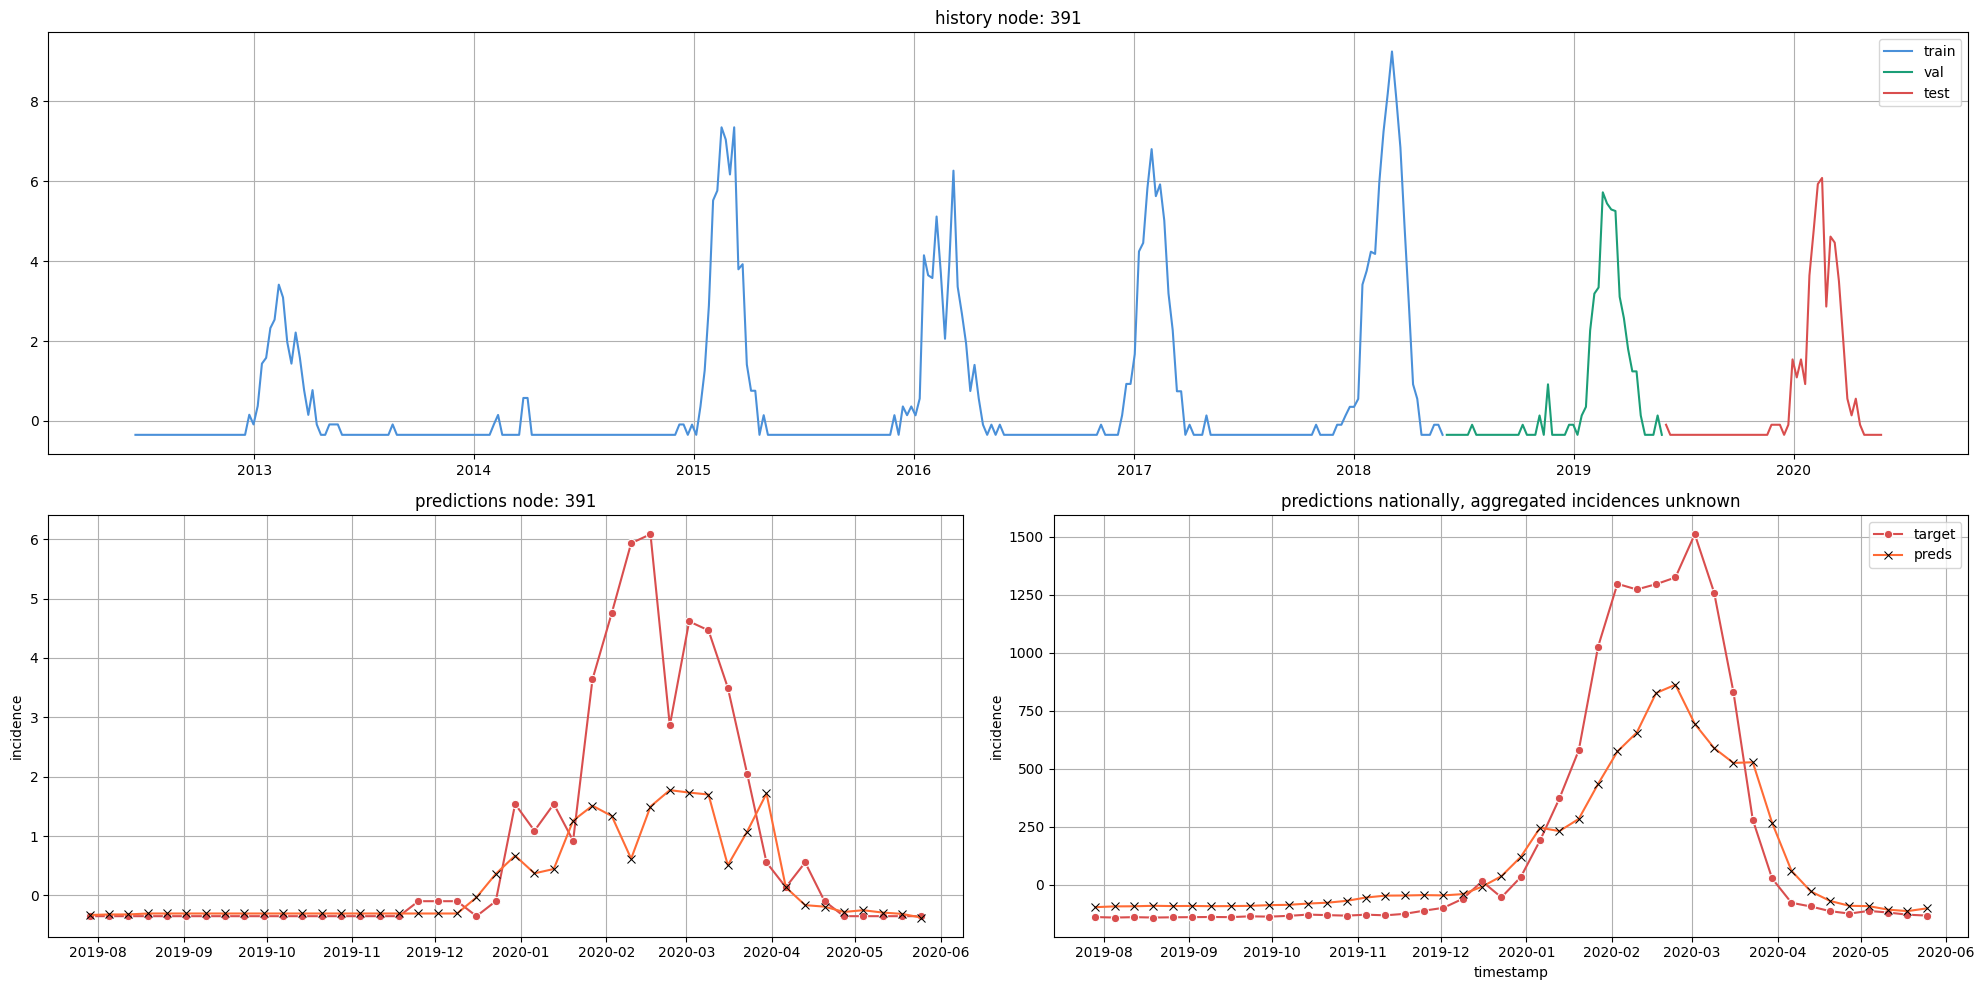

In [25]:
ml.show_forecasts(391, norm=True)

Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 1.2948, val loss: 2.0429 ✓ (new best)
Epoch 2 train loss: 1.1503, val loss: 2.0117 ✓ (new best)
Epoch 3 train loss: 1.1076, val loss: 2.0093 ✓ (new best)
Epoch 4 train loss: 1.1020, val loss: 2.0753 (patience: 1/15)
Epoch 5 train loss: 1.0937, val loss: 2.0119 (patience: 2/15)
Epoch 6 train loss: 1.0867, val loss: 2.0450 (patience: 3/15)
Epoch 7 train loss: 1.0922, val loss: 1.9997 ✓ (new best)
Epoch 8 train loss: 1.0666, val loss: 1.9375 ✓ (new best)
Epoch 9 train loss: 1.0619, val loss: 1.9106 ✓ (new best)
Epoch 10 train loss: 1.0336, val loss: 2.0602 (patience: 1/15)
Epoch 11 train loss: 1.0224, val loss: 1.9767 (patience: 2/15)
Epoch 12 train loss: 1.0133, val loss: 1.6503 ✓ (new best)
Epoch 13 train loss: 0.9467, val loss: 1.5856 ✓ (new best)
Epoch 14 train loss: 0.9322, val loss: 1.4596 ✓ (new best)
Epoch 15 train loss: 0.8899, val loss: 1.2660 ✓ (new best)
Epoch 16 

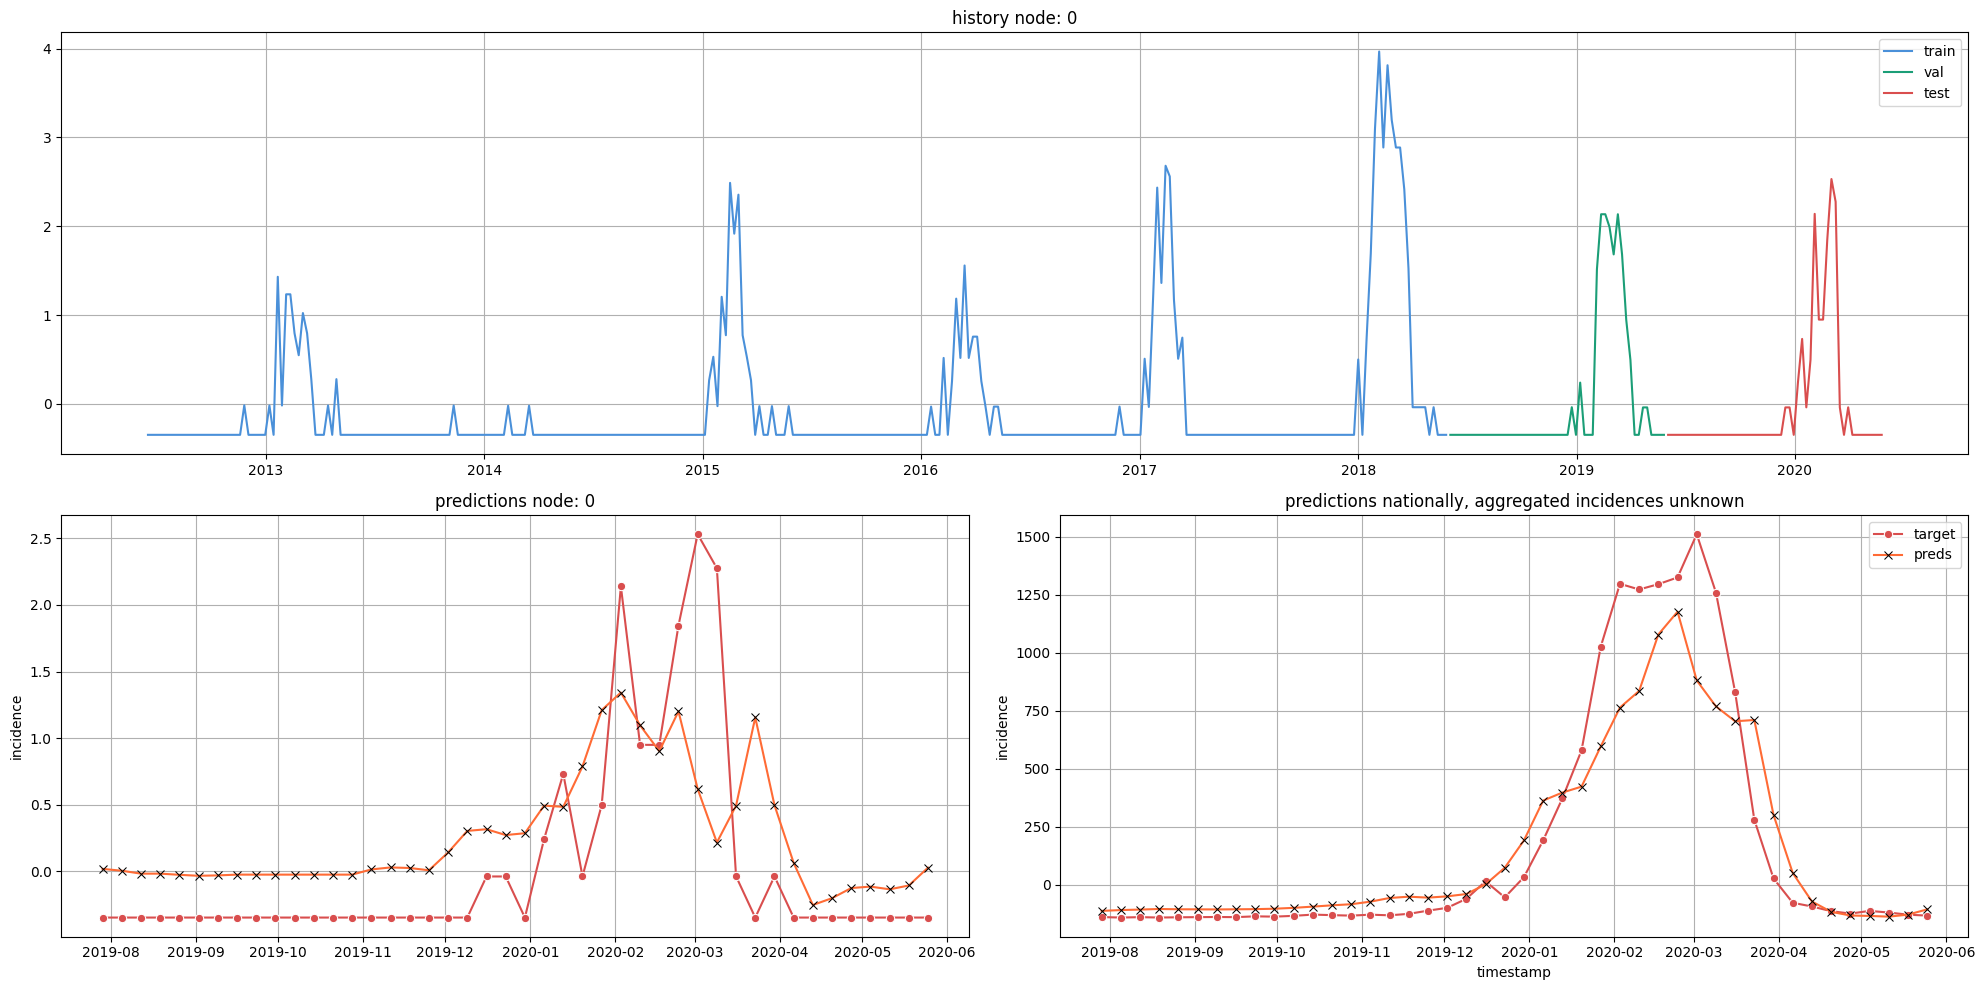

In [13]:
ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.001, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.8}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

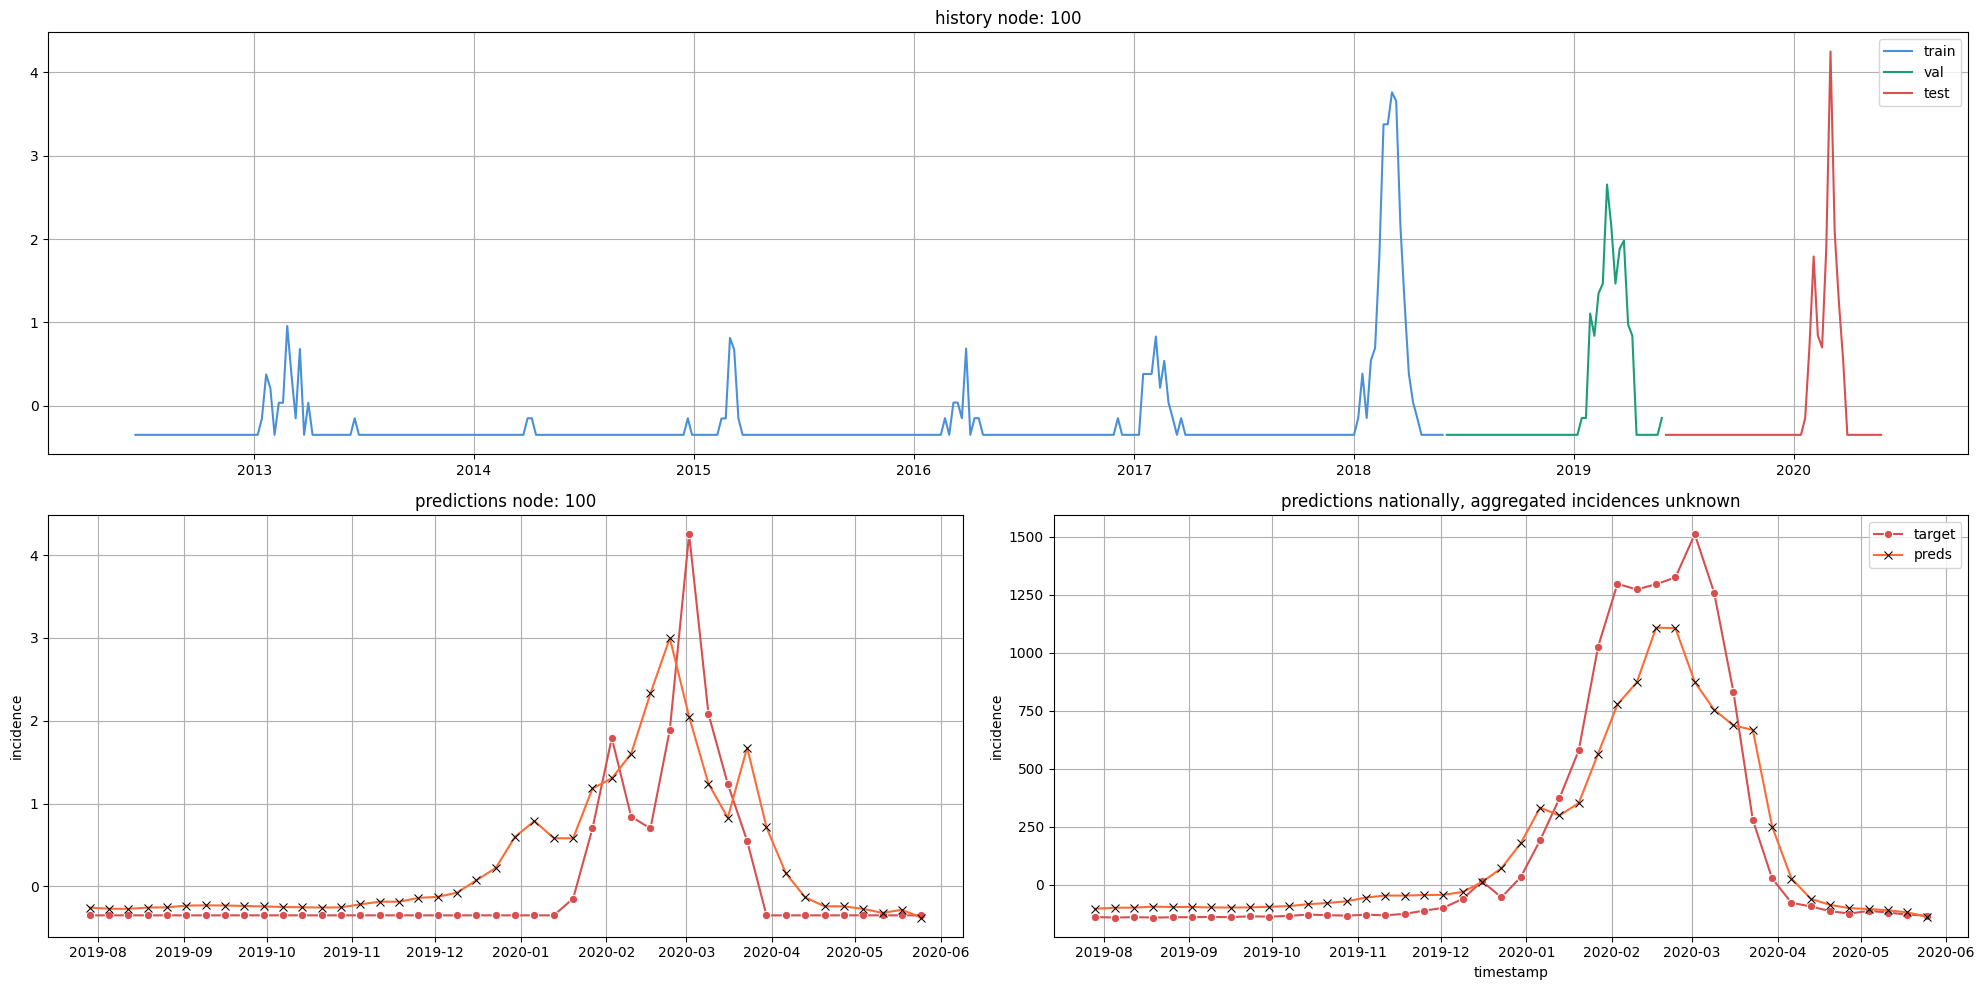

In [12]:
ml.show_forecasts(100,norm=True)

Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 2529], y=[411, 1], edge_weight=[2529])
Epoch 1 train loss: 1.9244, val loss: 2.4240 ✓ (new best)
Epoch 2 train loss: 1.4567, val loss: 2.1545 ✓ (new best)
Epoch 3 train loss: 1.3117, val loss: 2.0814 ✓ (new best)
Epoch 4 train loss: 1.2496, val loss: 1.9699 ✓ (new best)
Epoch 5 train loss: 1.1873, val loss: 1.9487 ✓ (new best)
Epoch 6 train loss: 1.1791, val loss: 1.9148 ✓ (new best)
Epoch 7 train loss: 1.1374, val loss: 1.9037 ✓ (new best)
Epoch 8 train loss: 1.1115, val loss: 1.7881 ✓ (new best)
Epoch 9 train loss: 1.0827, val loss: 1.8157 (patience: 1/15)
Epoch 10 train loss: 1.0380, val loss: 1.6872 ✓ (new best)
Epoch 11 train loss: 0.9948, val loss: 1.6533 ✓ (new best)
Epoch 12 train loss: 0.9473, val loss: 1.5644 ✓ (new best)
Epoch 13 train loss: 0.9068, val loss: 2.2022 (patience: 1/15)
Epoch 14 train loss: 0.9396, val loss: 1.6467 (patience: 2/15)
Epoch 15 train loss: 0.9247, val loss: 1.5598 ✓ (new best)
Epoch 16 train lo

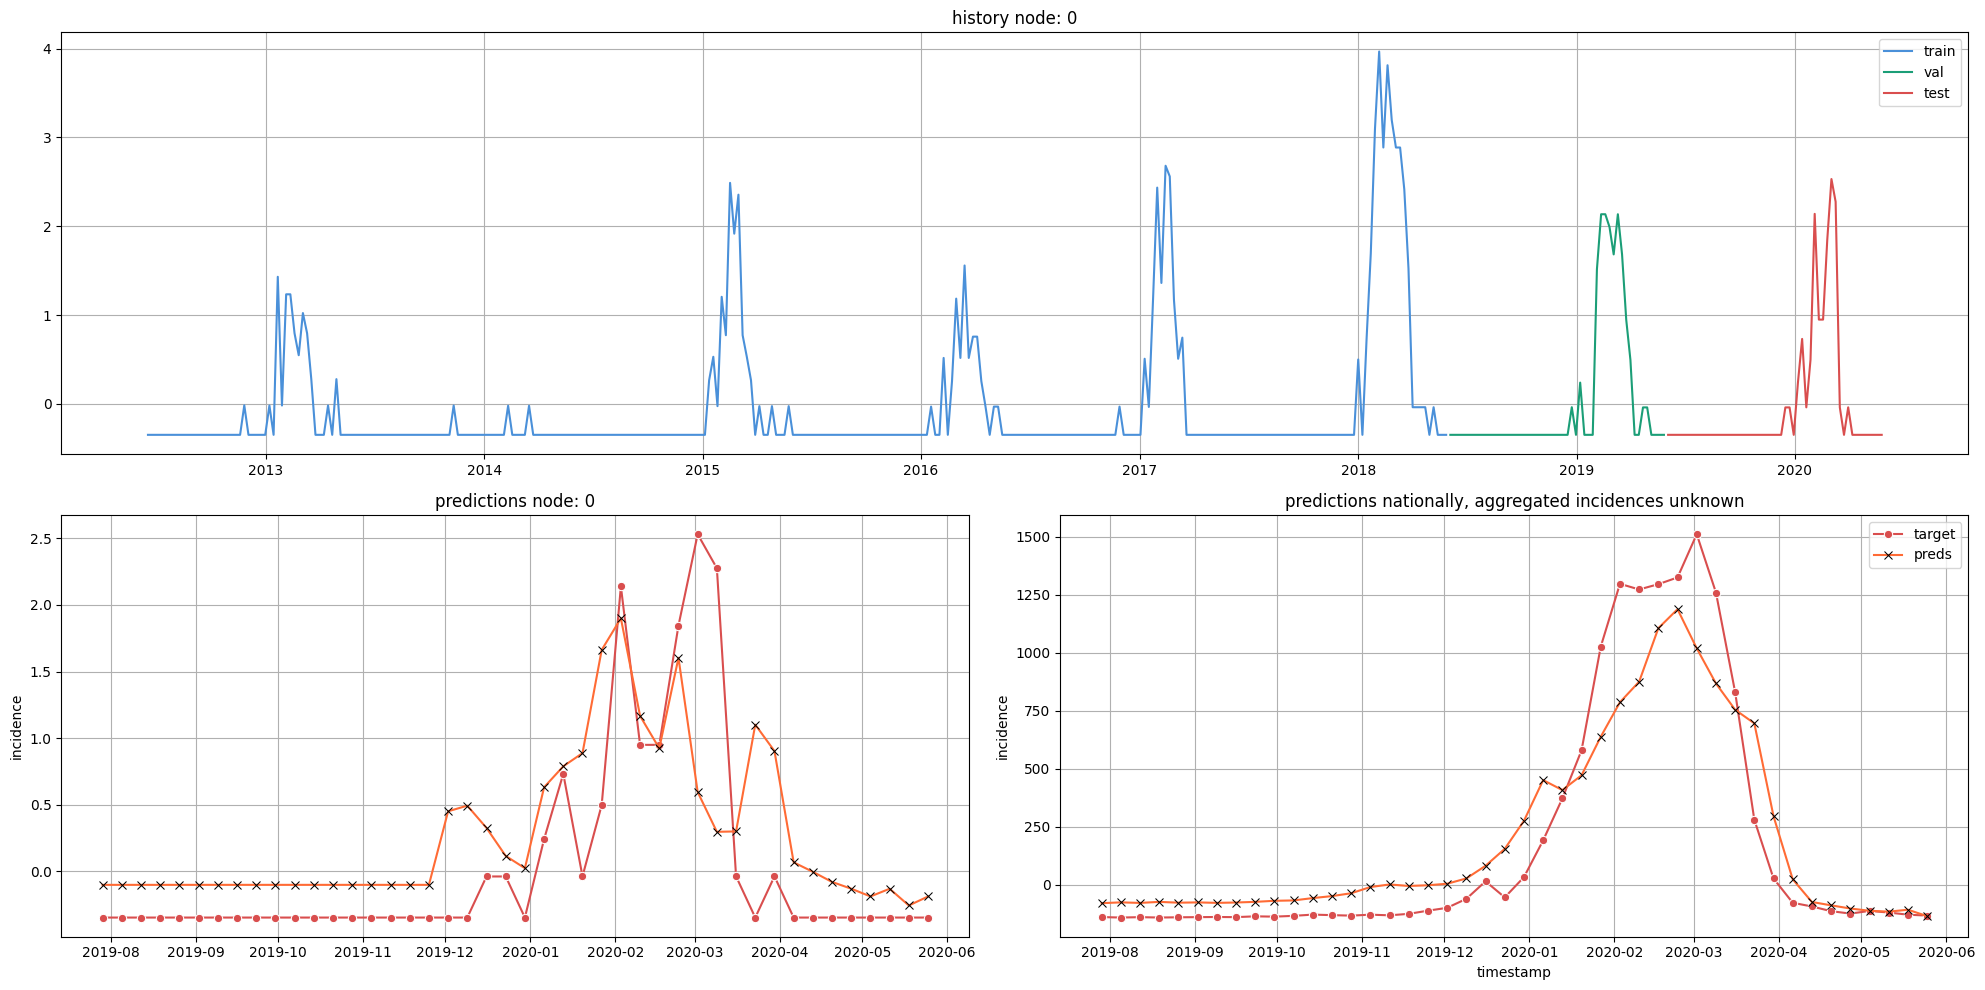

In [88]:
ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.9}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

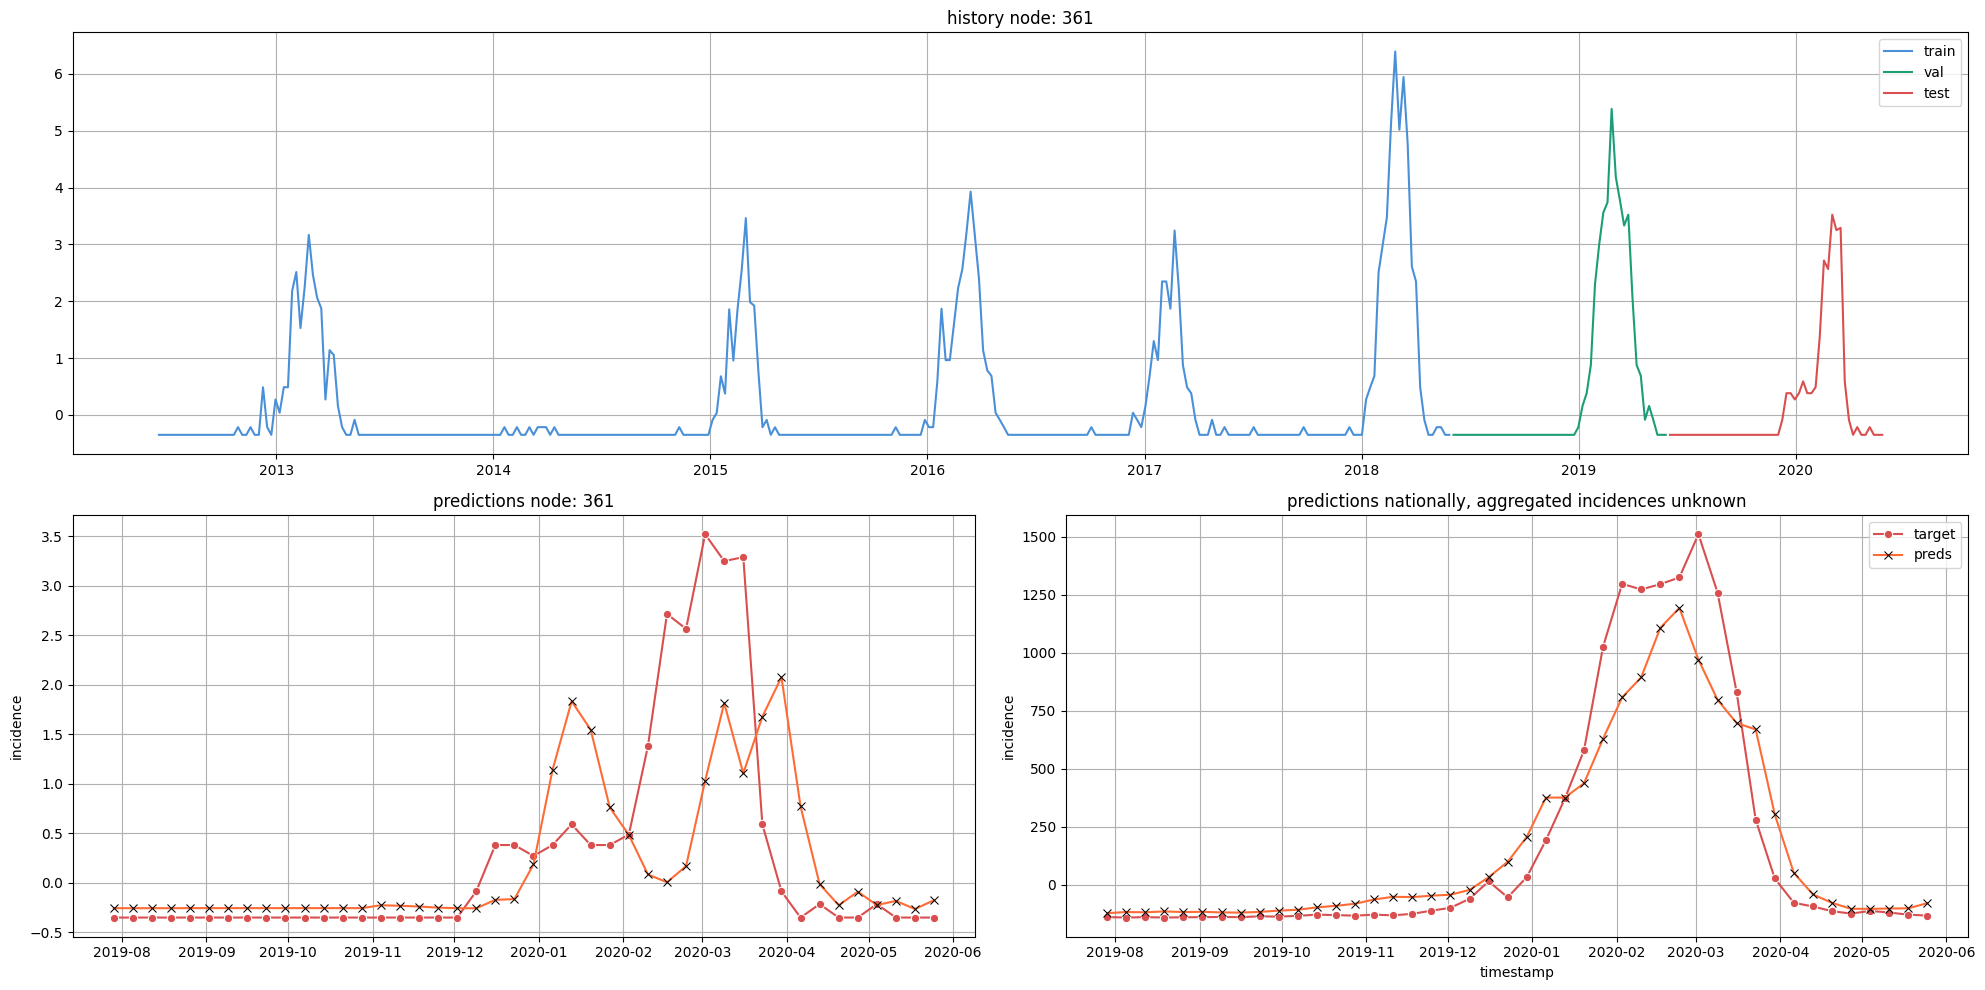

In [94]:
ml.show_forecasts(361,norm=True)

Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 1.2398, val loss: 2.0285 ✓ (new best)
Epoch 2 train loss: 1.1627, val loss: 2.0219 ✓ (new best)
Epoch 3 train loss: 1.1123, val loss: 2.0058 ✓ (new best)
Epoch 4 train loss: 1.0990, val loss: 1.9987 ✓ (new best)
Epoch 5 train loss: 1.0909, val loss: 1.9509 ✓ (new best)
Epoch 6 train loss: 1.0664, val loss: 1.8896 ✓ (new best)
Epoch 7 train loss: 1.0435, val loss: 1.7846 ✓ (new best)
Epoch 8 train loss: 1.0128, val loss: 1.7772 ✓ (new best)
Epoch 9 train loss: 1.0151, val loss: 1.6115 ✓ (new best)
Epoch 10 train loss: 0.9284, val loss: 1.4460 ✓ (new best)
Epoch 11 train loss: 0.8764, val loss: 1.3418 ✓ (new best)
Epoch 12 train loss: 0.8363, val loss: 1.5845 (patience: 1/15)
Epoch 13 train loss: 0.8405, val loss: 1.5155 (patience: 2/15)
Epoch 14 train loss: 0.8601, val loss: 1.2325 ✓ (new best)
Epoch 15 train loss: 0.8306, val loss: 1.2590 (patience: 1/15)
Epoch 16 train lo

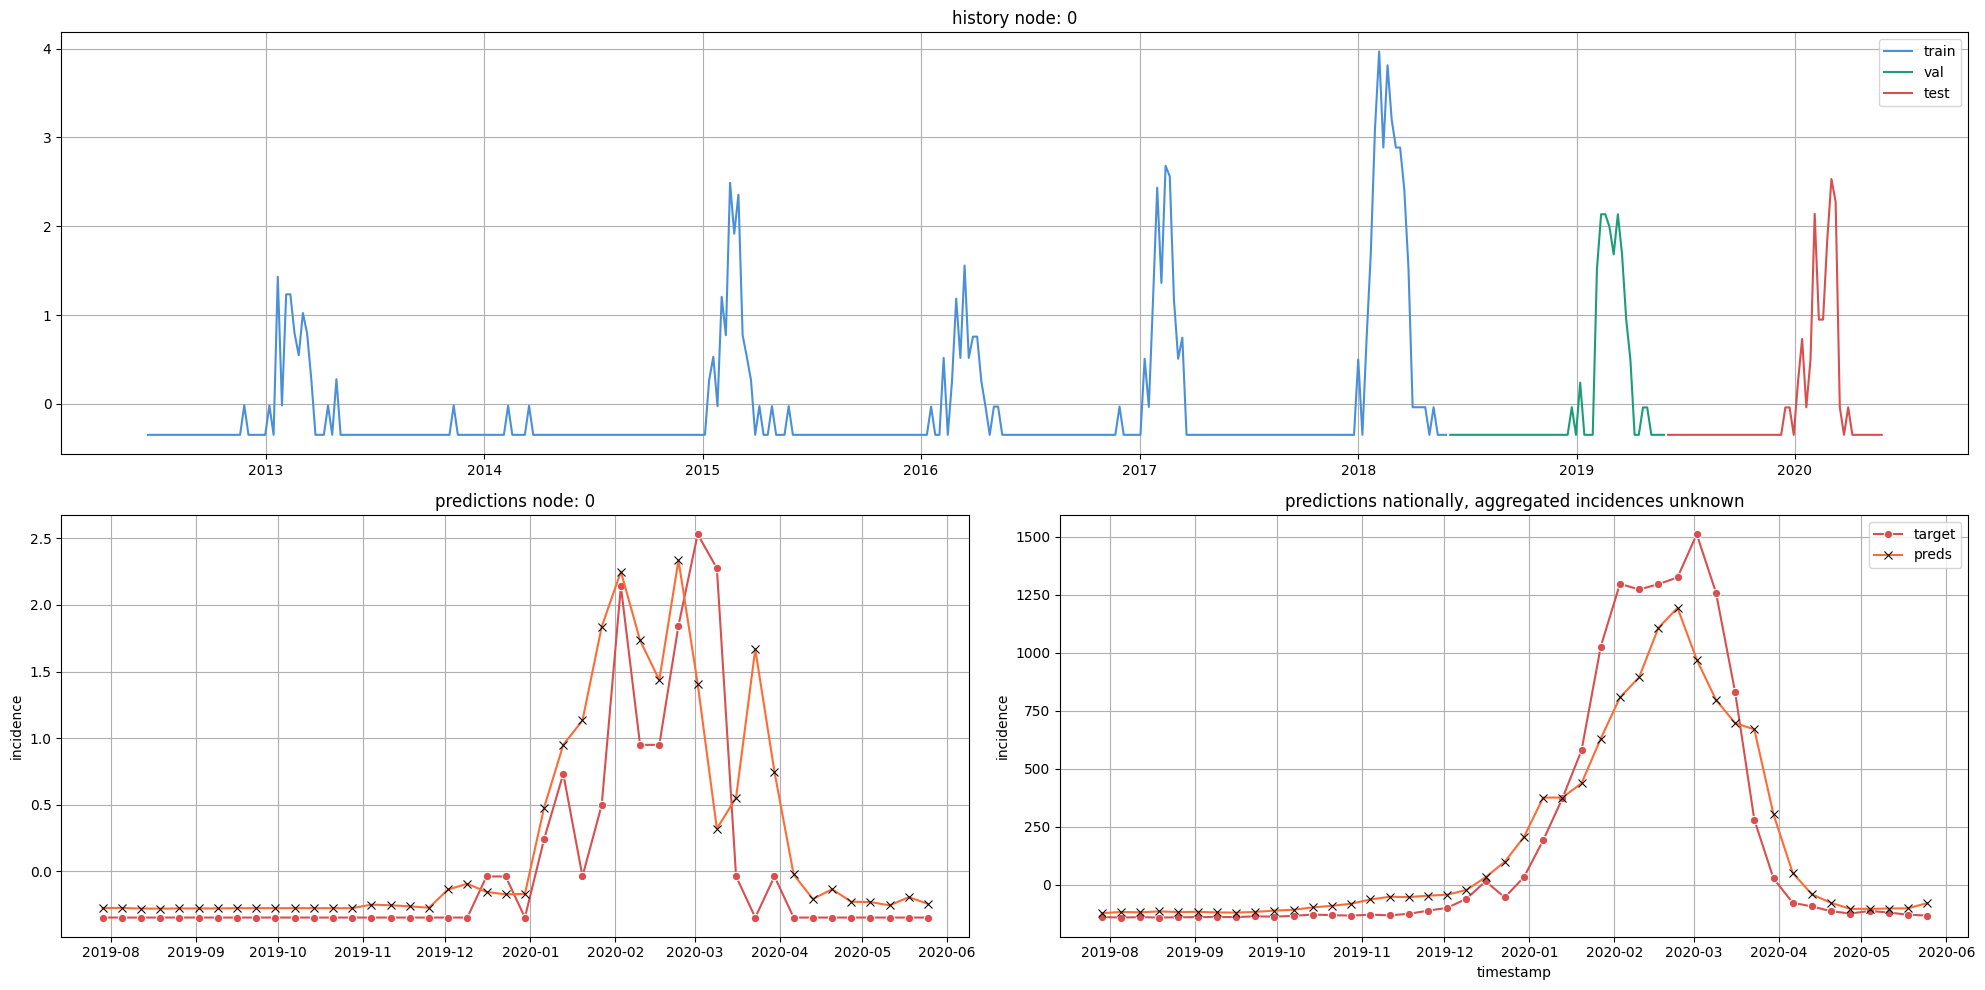

In [90]:
ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader3)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.9}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 411], y=[411, 1], edge_weight=[411])
Epoch 1 train loss: 1.1990, val loss: 2.0215 ✓ (new best)
Epoch 2 train loss: 1.1153, val loss: 2.0149 ✓ (new best)
Epoch 3 train loss: 1.0866, val loss: 2.0161 (patience: 1/15)
Epoch 4 train loss: 1.0699, val loss: 2.0128 ✓ (new best)
Epoch 5 train loss: 1.0599, val loss: 1.9556 ✓ (new best)
Epoch 6 train loss: 1.0433, val loss: 1.9285 ✓ (new best)
Epoch 7 train loss: 1.0282, val loss: 1.7534 ✓ (new best)
Epoch 8 train loss: 0.9845, val loss: 1.5466 ✓ (new best)
Epoch 9 train loss: 0.9219, val loss: 1.4606 ✓ (new best)
Epoch 10 train loss: 0.8873, val loss: 1.1964 ✓ (new best)
Epoch 11 train loss: 0.8618, val loss: 1.1565 ✓ (new best)
Epoch 12 train loss: 0.8509, val loss: 1.1293 ✓ (new best)
Epoch 13 train loss: 0.8624, val loss: 1.0917 ✓ (new best)
Epoch 14 train loss: 0.8449, val loss: 1.0717 ✓ (new best)
Epoch 15 train loss: 0.8347, val loss: 1.0573 ✓ (new best)
Epoch 16 train loss: 0.8332

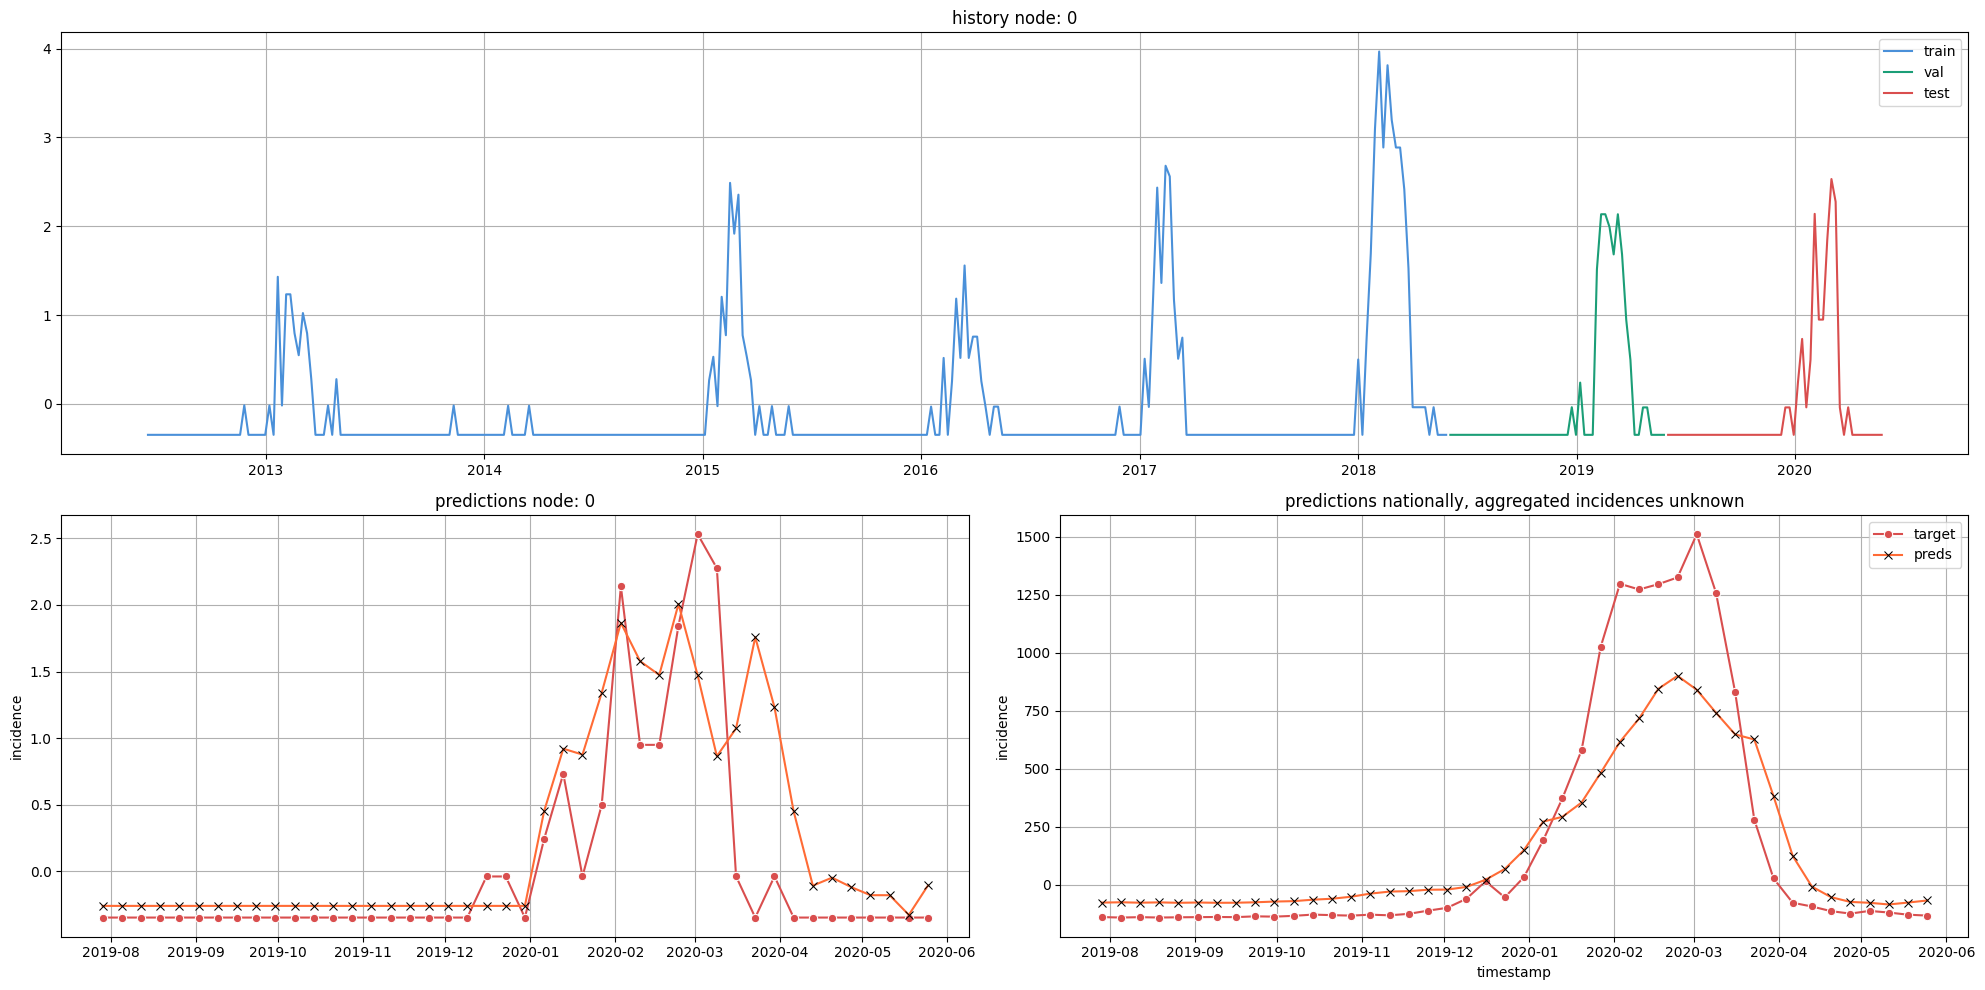

In [10]:
ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader1)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.9}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

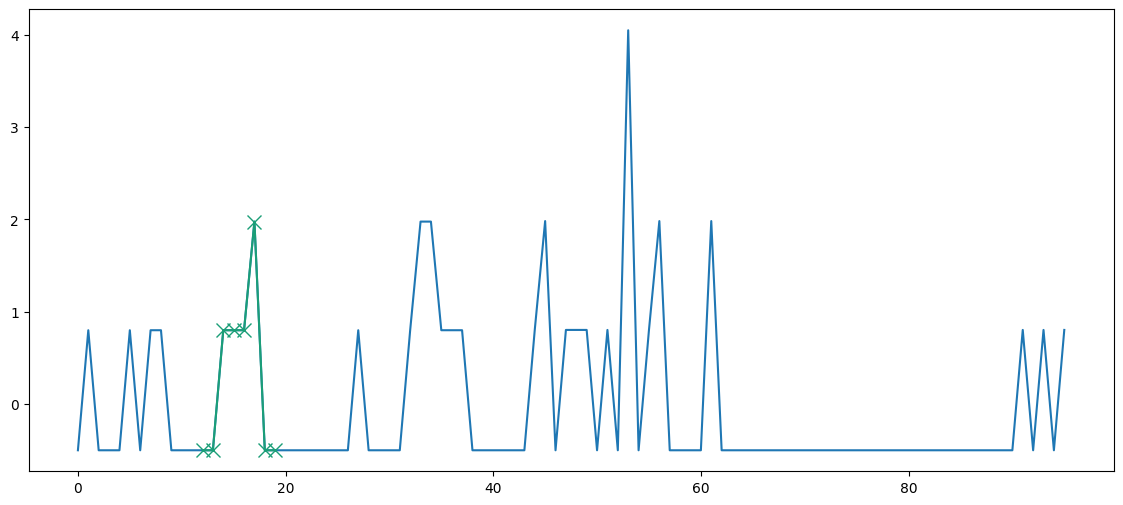

In [29]:
gnnloader1.preview_dataloader(0)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


(<Figure size 2200x600 with 2 Axes>, <Axes: title={'center': 'node: 1'}>)

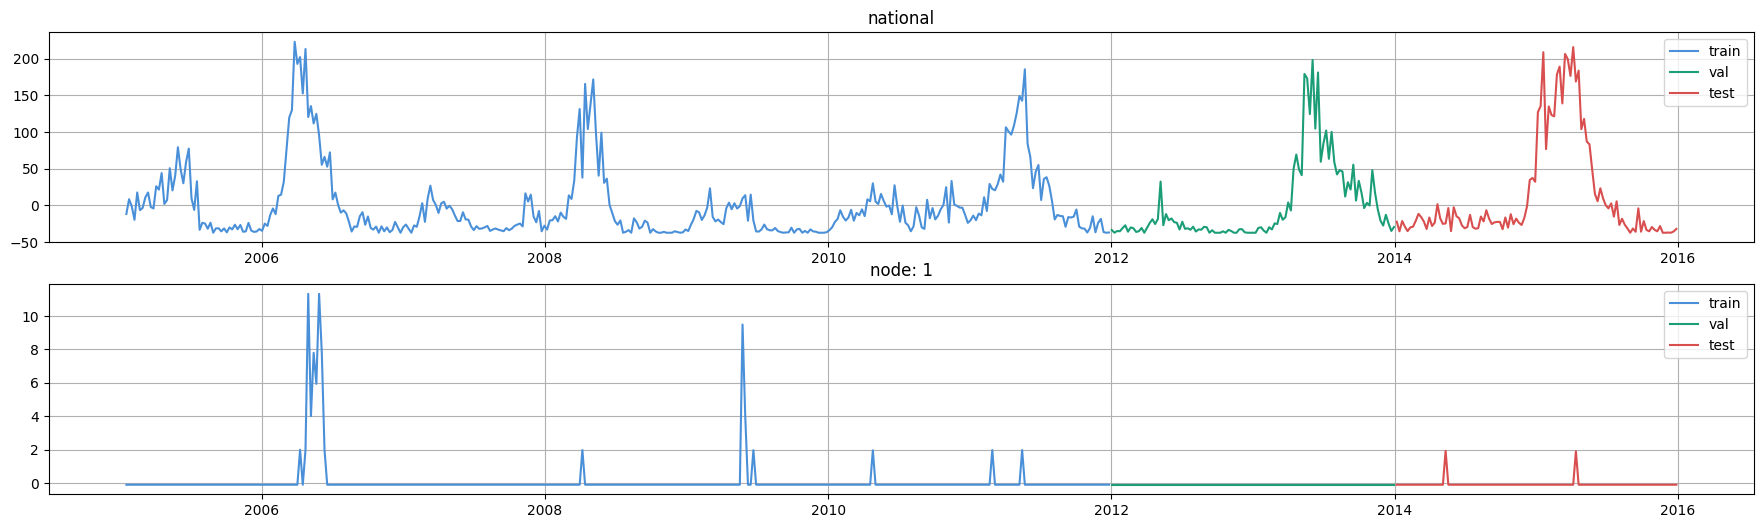

In [45]:

n_periods = 8
n_epochs  = 250
horizon   = 1
lags      = range(2,3)


epidata = EpiDataLoader('measles', data_env, aggr_level= '03', min_date='2004-01-01',max_date='2016-01-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2012-01-01','2014-01-01','zscore')
epidata.add_lagged_features(lags = lags)
epidata.preview()


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 1.1010, val loss: 1.0234 (patience: 1/15)
Epoch 2 train loss: 1.0498, val loss: 1.0239 (patience: 2/15)
Epoch 3 train loss: 1.0306, val loss: 1.0137 ✓ (new best)
Epoch 4 train loss: 1.0194, val loss: 1.0061 ✓ (new best)
Epoch 5 train loss: 1.0105, val loss: 1.0015 ✓ (new best)
Epoch 6 train loss: 1.0046, val loss: 0.9990 ✓ (new best)
Epoch 7 train loss: 1.0000, val loss: 0.9977 ✓ (new best)
Epoch 8 train loss: 0.9965, val loss: 0.9971 ✓ (new best)
Epoch 9 train loss: 0.9940, val loss: 0.9969 ✓ (new best)
Epoch 10 train loss: 0.9921, val loss: 0.9967 ✓ (new best)
Epoch 11 train loss: 0.9904, val loss: 0.9968 (patience: 1/15)
Epoch 12 train loss: 0.9889, val loss: 0.9966 ✓ (new best)
Epoch 13 train loss: 0.9878, val loss: 0.9967 (patience: 1/15)
Epoch 14 train loss: 0.9870, val loss: 0.9966 (patience: 2/15)
Epoch 15 train loss: 0.9856, val loss: 0.9966 (patience: 3/15)
Epoch

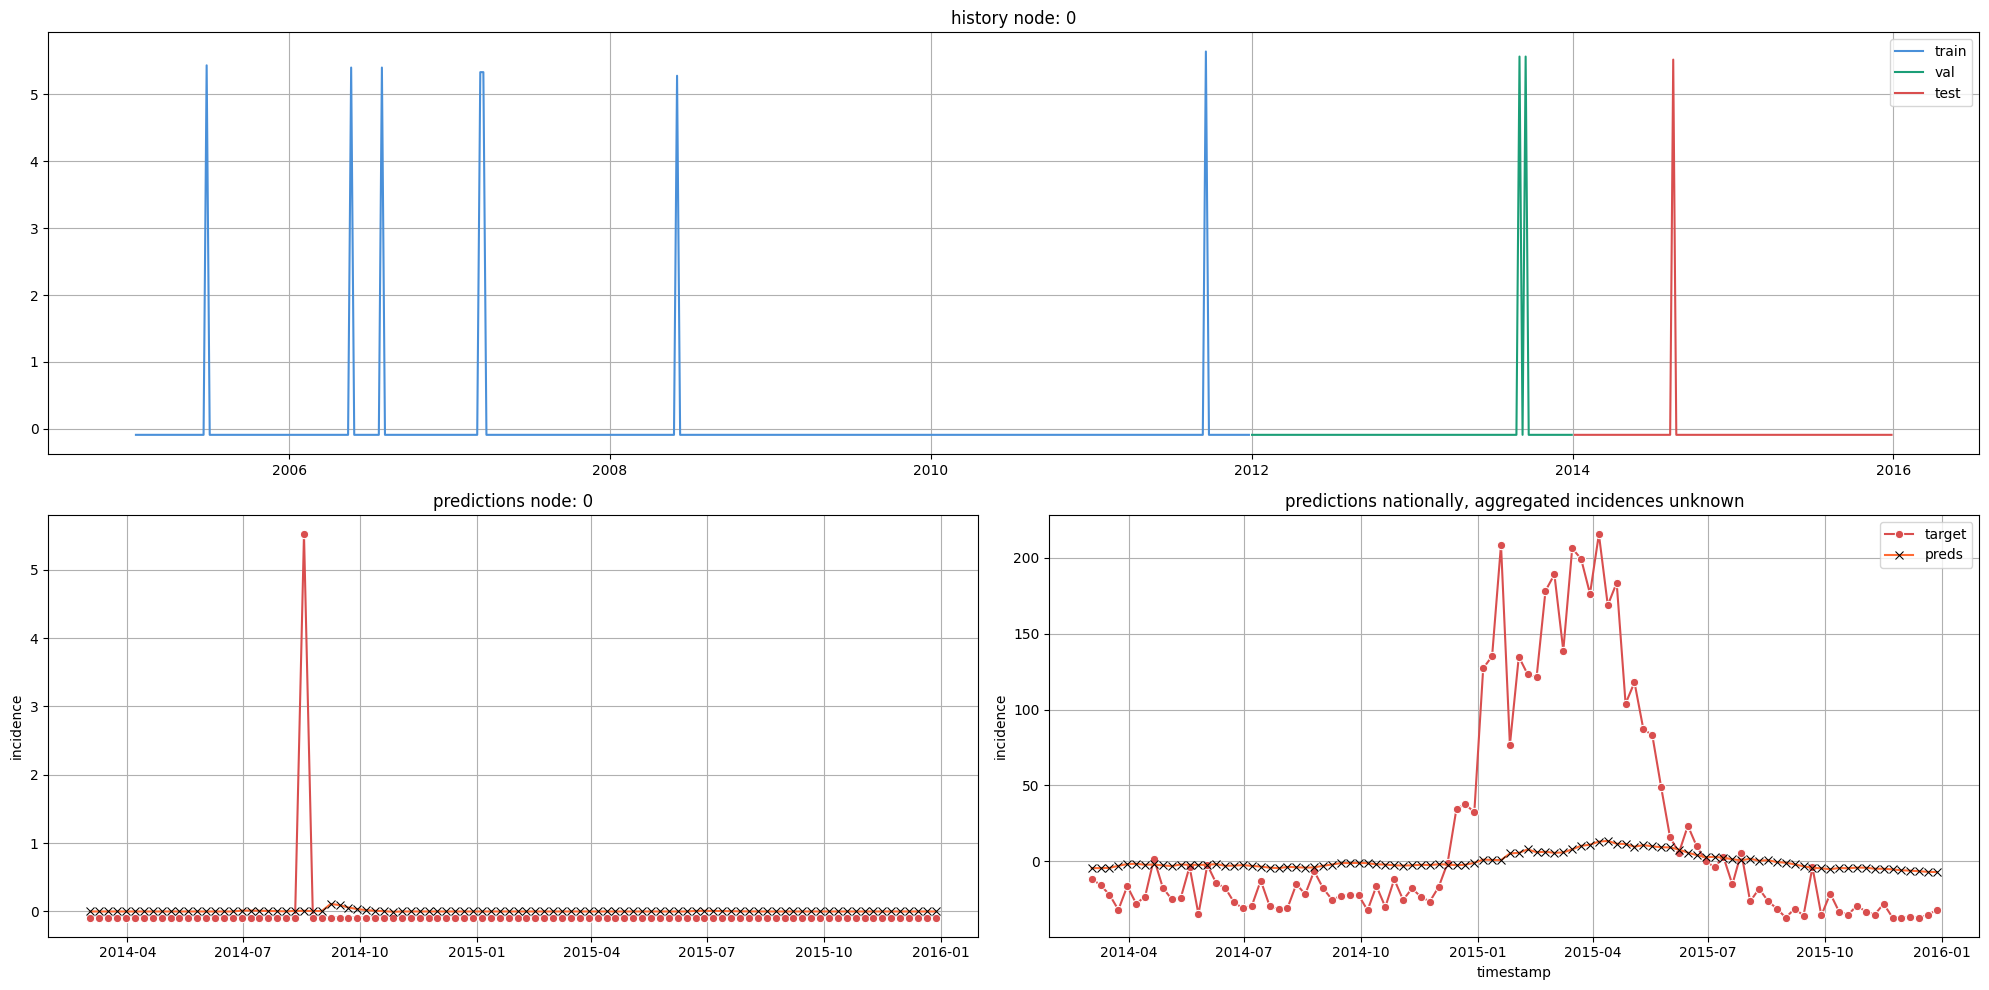

In [50]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from torch_geometric.data import Data
import os
import sys

from tests import *

from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.epidataloader import EpiDataLoader
from src.models.gatv2 import GRU_GATv2_Model_Wrapper

n_periods = 8
n_epochs  = 250
horizon   = 1
lags      = range(2,3)

epidata = EpiDataLoader('measles', data_env, aggr_level= '03', min_date='2004-01-01',max_date='2016-01-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2012-01-01','2014-01-01','zscore')
epidata.add_lagged_features(lags = lags)
# epidata.preview()
if 'population_size' in epidata.feature_columns:
    epidata.feature_columns.remove('population_size')

gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
# gnnloader1.preview_dataloader(1, timepoint = 10)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader4 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)


ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader3)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.00025, n_epochs=n_epochs, scheduler_kwargs={'step_size':15, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from torch_geometric.data import Data
import os
import sys

from tests import *

from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.epidataloader import EpiDataLoader
from src.models.gatv2 import GRU_GATv2_Model_Wrapper

n_periods = 8
n_epochs  = 250
horizon   = 1
lags      = range(2,3)

epidata = EpiDataLoader('covid', data_env, aggr_level= '03', min_date='2020-07-01',max_date='2023-01-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2022-01-01','2022-06-01','zscore')
epidata.add_lagged_features(lags)
epidata.preview()
# epidata.preview()
if 'population_size' in epidata.feature_columns:
    epidata.feature_columns.remove('population_size')

gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
# gnnloader1.preview_dataloader(1, timepoint = 10)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader4 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)


ml = GRU_GATv2_Model_Wrapper(dataloader = gnnloader3)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.00025, n_epochs=n_epochs, scheduler_kwargs={'step_size':15, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Dataloader Snapshot: Data(x=[411, 3, 8], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 3.6109, val loss: 1.1586 ✓ (new best)


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 411], y=[411, 1], edge_weight=[411])
Epoch 1 train loss: 0.8060, val loss: 3.4934 ✓ (new best)
Epoch 2 train loss: 0.7855, val loss: 3.1986 ✓ (new best)
Epoch 3 train loss: 0.7648, val loss: 2.9538 ✓ (new best)
Epoch 4 train loss: 0.7546, val loss: 2.7514 ✓ (new best)
Epoch 5 train loss: 0.7399, val loss: 2.5797 ✓ (new best)
Epoch 6 train loss: 0.7328, val loss: 2.4466 ✓ (new best)
Epoch 7 train loss: 0.7245, val loss: 2.3441 ✓ (new best)
Epoch 8 train loss: 0.7164, val loss: 2.2582 ✓ (new best)
Epoch 9 train loss: 0.7102, val loss: 2.1863 ✓ (new best)
Epoch 10 train loss: 0.7074, val loss: 2.1414 ✓ (new best)
Epoch 11 train loss: 0.7016, val loss: 2.1024 ✓ (new best)
Epoch 12 train loss: 0.7004, val loss: 2.0703 ✓ (new best)
Epoch 13 train loss: 0.6949, val loss: 2.0418 ✓ (new best)
Epoch 14 train loss: 0.6883, val loss: 2.0168 ✓ (new best)
Epoch 15 train loss: 0.6905, val loss: 2.0031 ✓ (new best)
Epoch 16 train loss: 0.6863, va

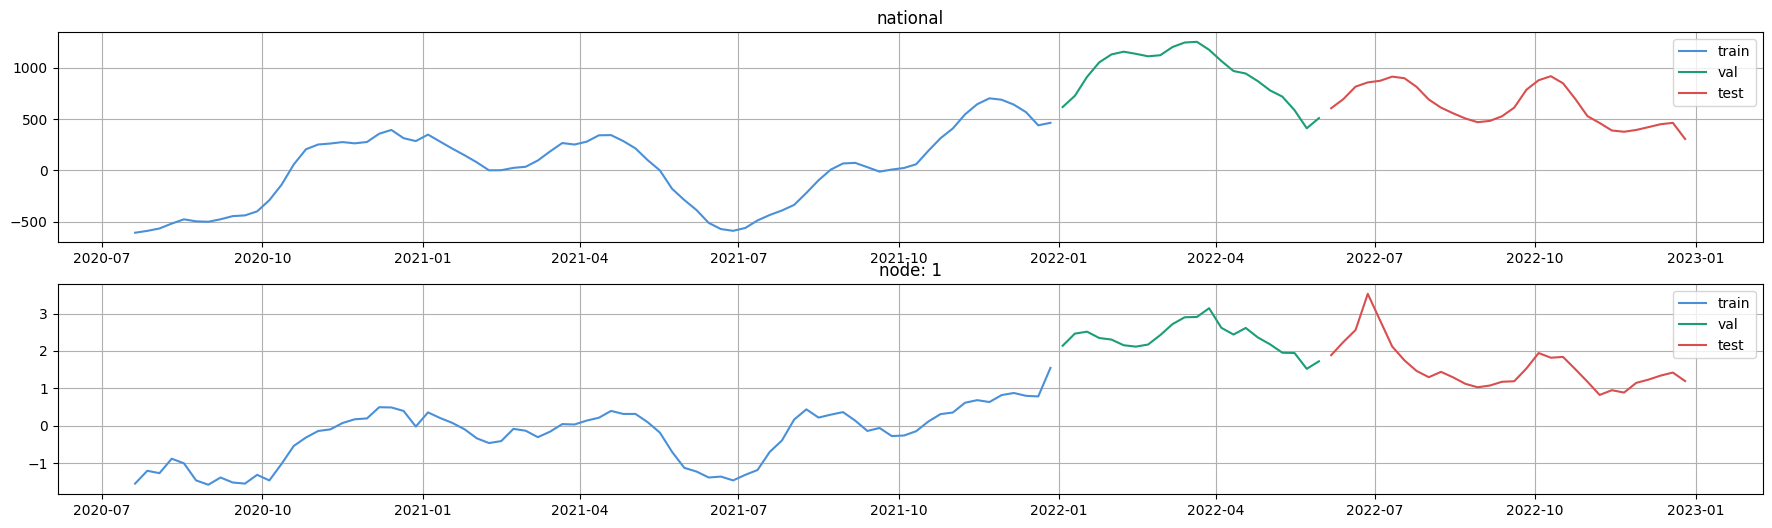

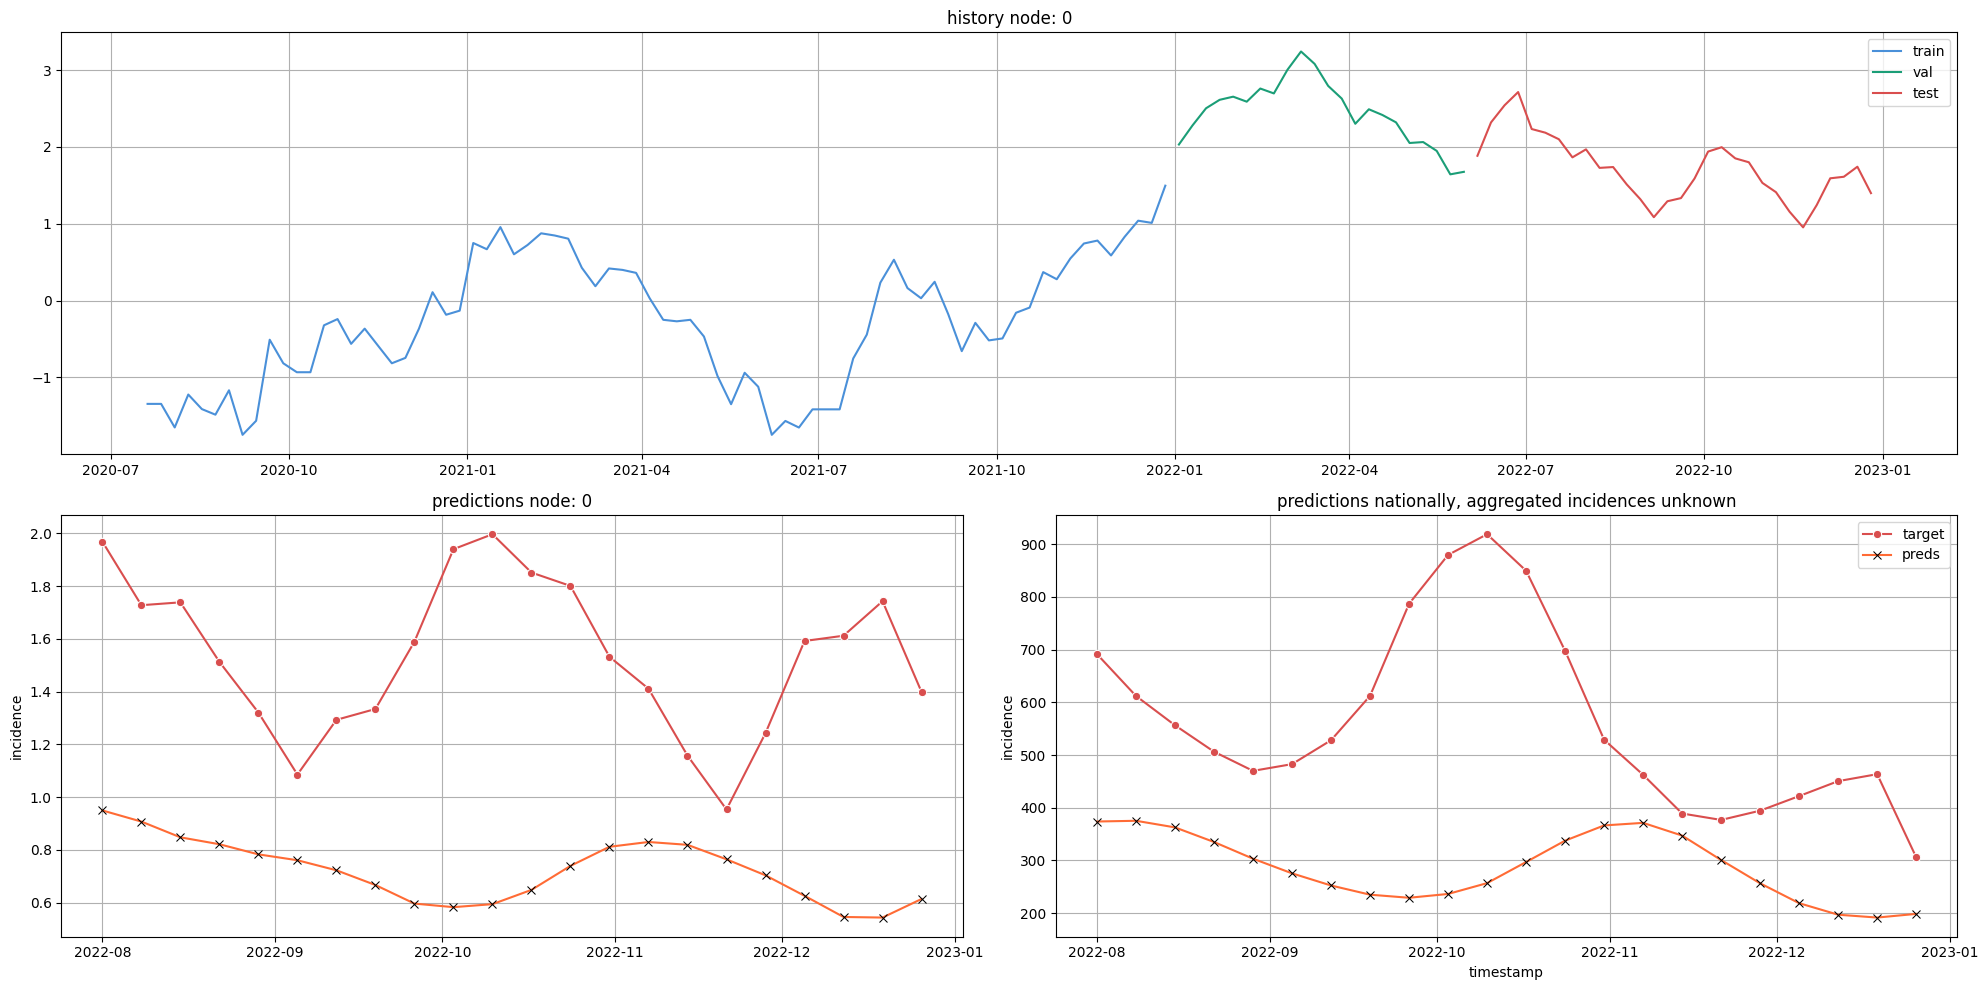

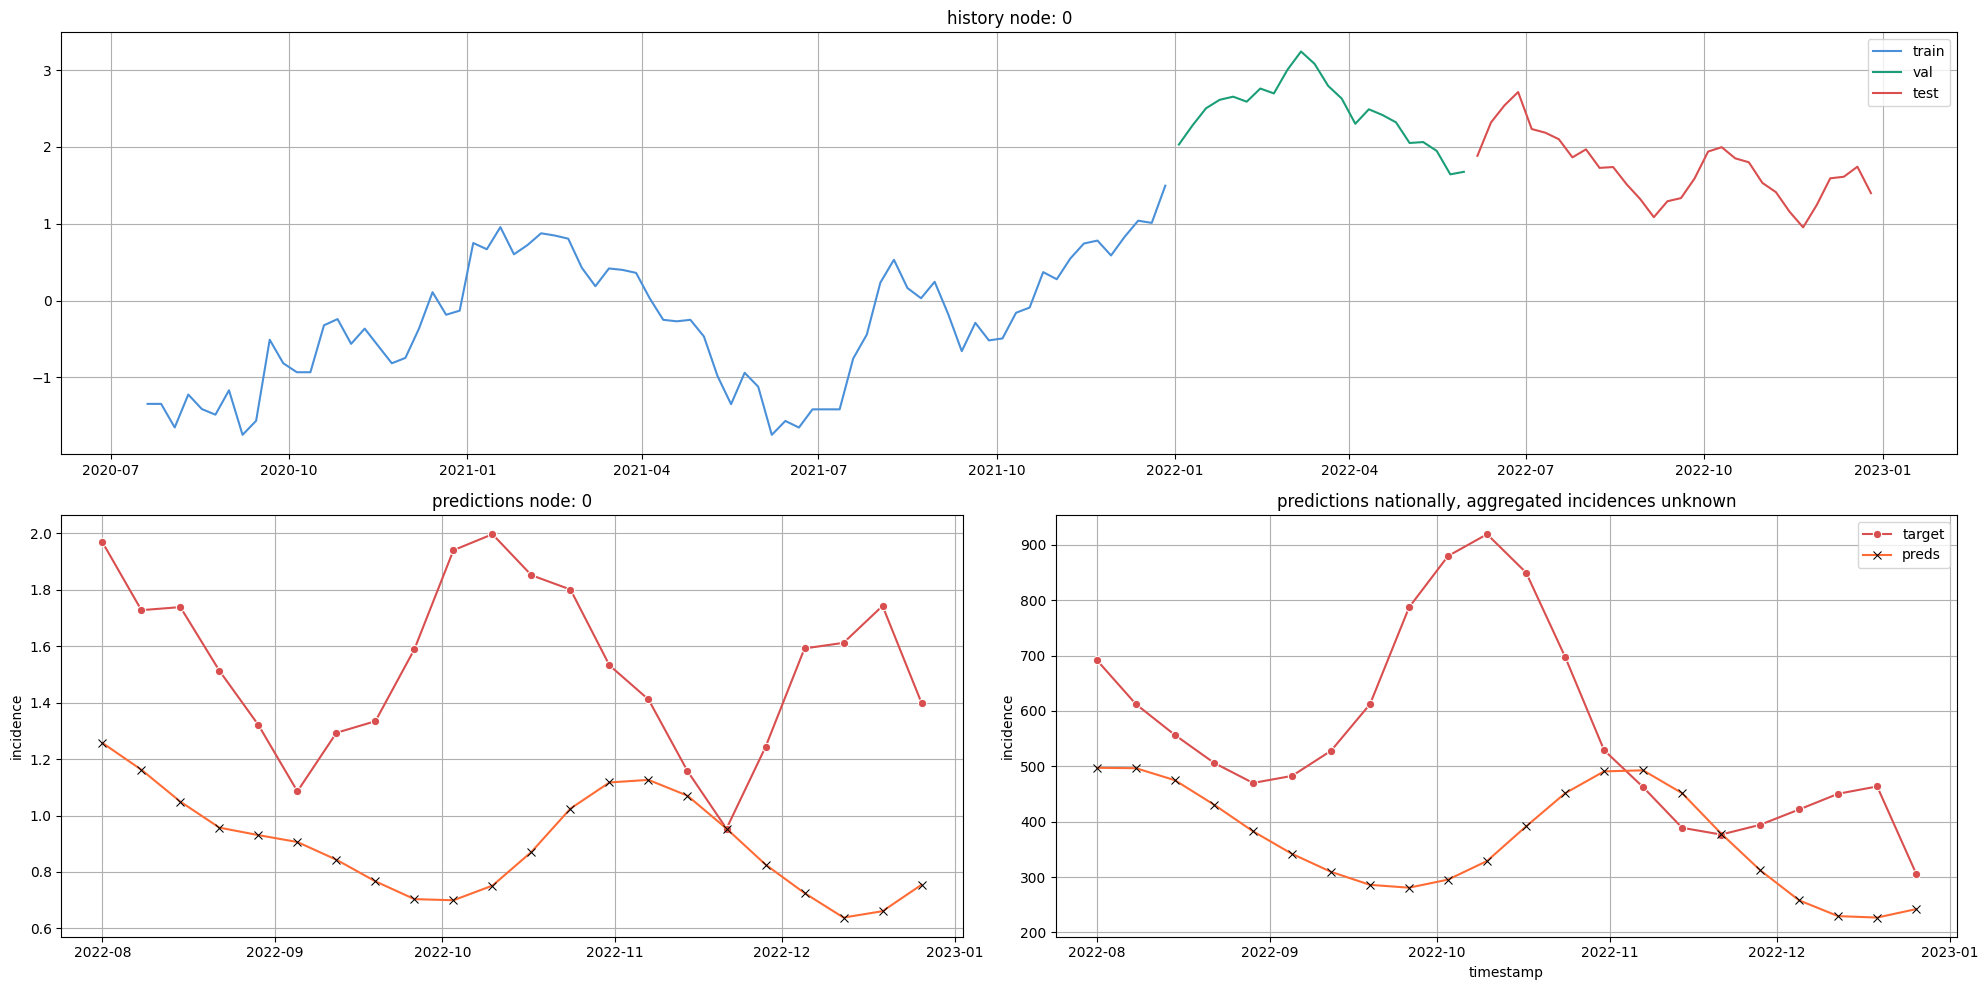

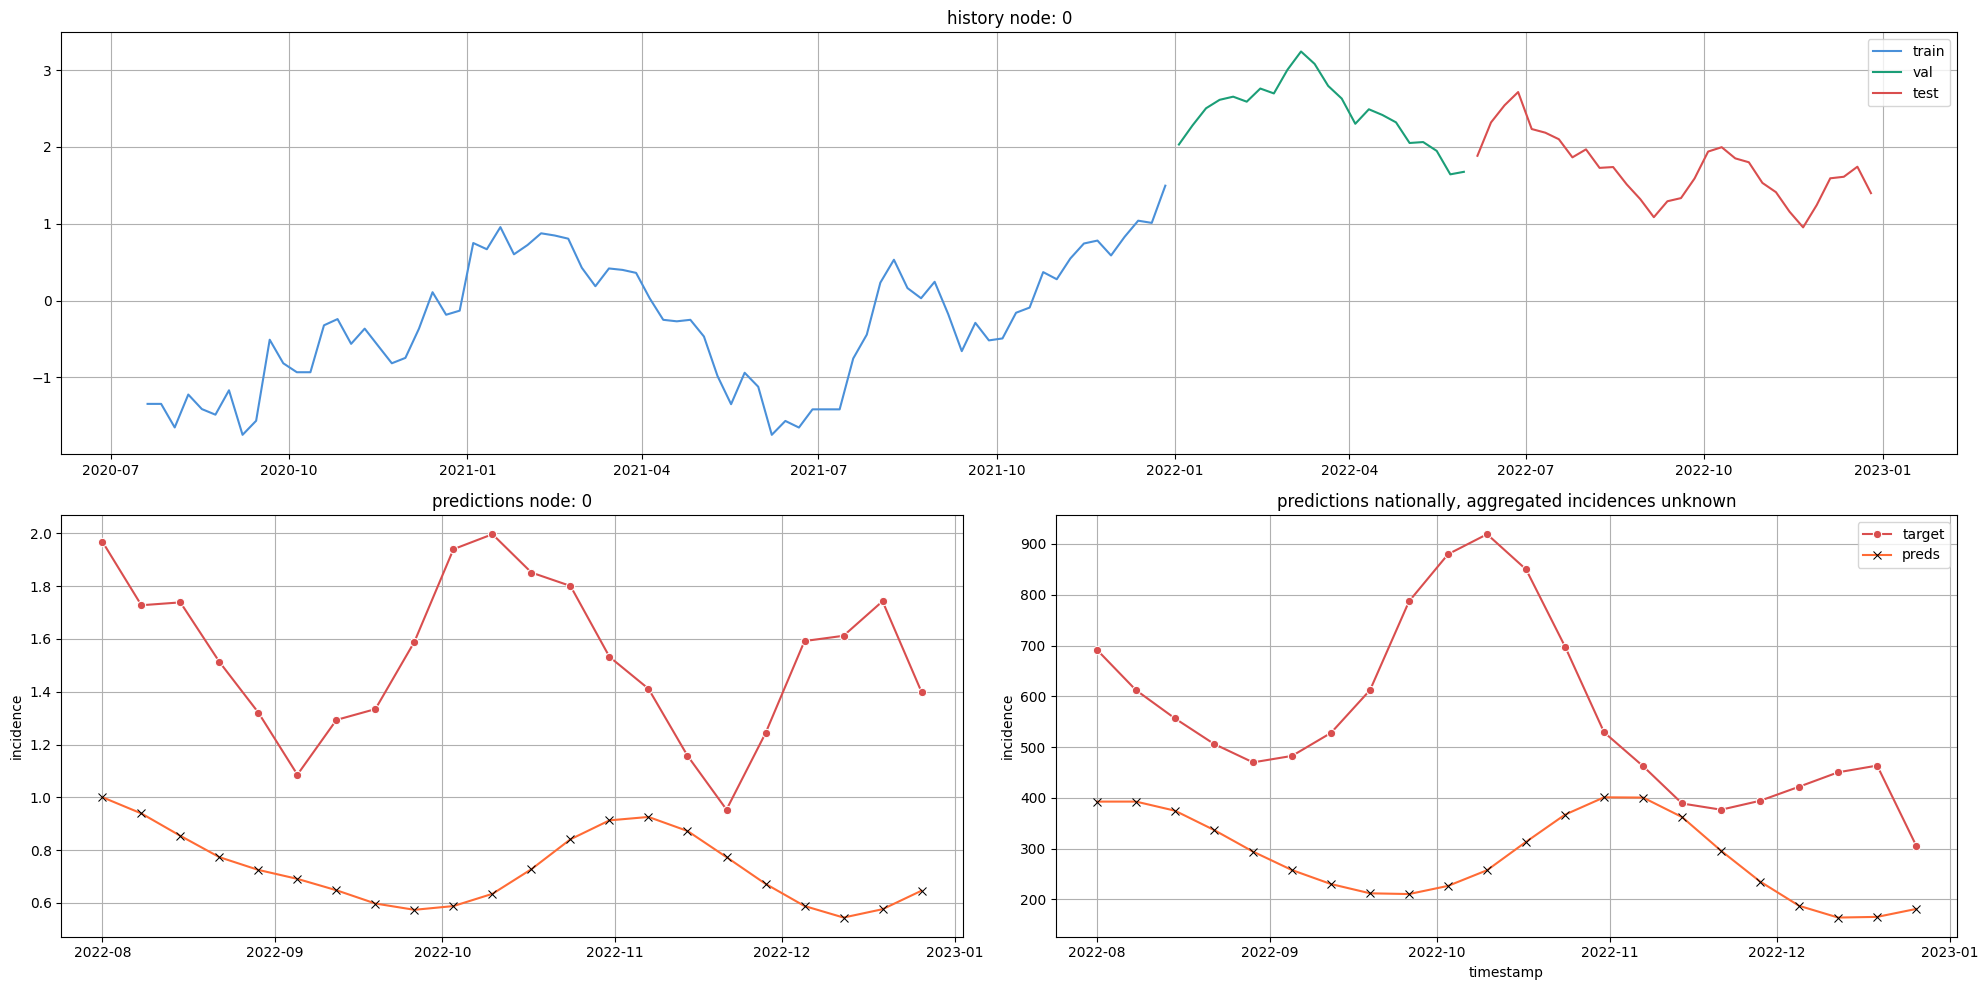

In [9]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import os
import sys

from tests import *

from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.epidataloader import EpiDataLoader
from src.models.gatv2_paper import PaperGRU_GATv2_Model_Wrapper

n_periods = 8
n_epochs  = 250
horizon   = 1
lags      = range(2,3)


epidata = EpiDataLoader('covid', data_env, aggr_level= '03', min_date='2020-07-01',max_date='2023-01-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2022-01-01','2022-06-01','zscore')
epidata.add_lagged_features(lags)
epidata.preview()

if 'population_size' in epidata.feature_columns:
    epidata.feature_columns.remove('population_size')

gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
# gnnloader1.preview_dataloader(1, timepoint = 10)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)


lr = 0.0001/5

ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader1)
ml.set_model_hparams()
ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader3)
ml.set_model_hparams()
ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


(<Figure size 2200x600 with 2 Axes>, <Axes: title={'center': 'node: 1'}>)

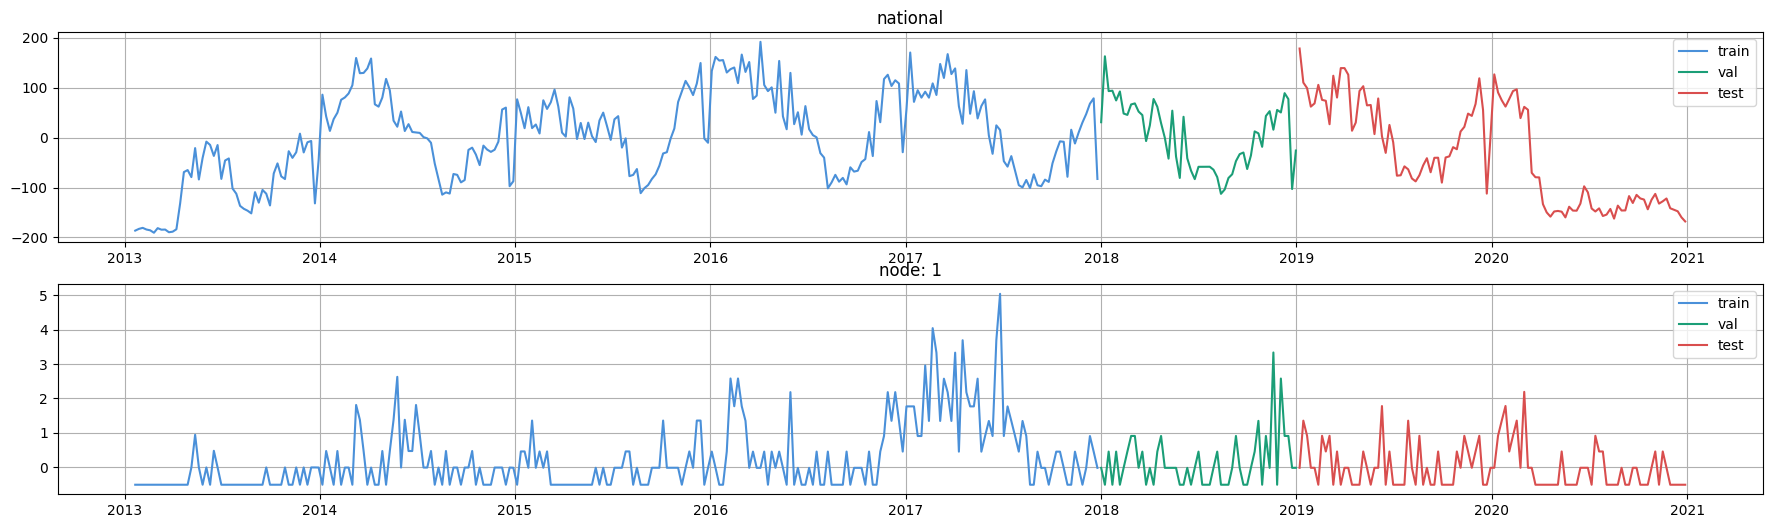

In [26]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import os
import sys

from tests import *

from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.epidataloader import EpiDataLoader
from src.models.gatv2_paper import PaperGRU_GATv2_Model_Wrapper

n_periods = 8
n_epochs  = 250
horizon   = 1
lags      = range(2,3)


epidata = EpiDataLoader('chickenpox', data_env, aggr_level= '03', min_date='2013-01-01',max_date='2021-01-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-01-01','2019-01-01','zscore')
epidata.add_lagged_features(lags)
epidata.preview()


Dataloader Snapshot: Data(x=[411, 1, 8], edge_index=[2, 411], y=[411, 1], edge_weight=[411])
Epoch 1 train loss: 1.0284, val loss: 0.8387 (patience: 1/15)
Epoch 2 train loss: 1.0279, val loss: 0.8392 (patience: 2/15)
Epoch 3 train loss: 1.0277, val loss: 0.8393 (patience: 3/15)
Epoch 4 train loss: 1.0274, val loss: 0.8394 (patience: 4/15)
Epoch 5 train loss: 1.0275, val loss: 0.8394 (patience: 5/15)
Epoch 6 train loss: 1.0273, val loss: 0.8395 (patience: 6/15)
Epoch 7 train loss: 1.0273, val loss: 0.8395 (patience: 7/15)
Epoch 8 train loss: 1.0272, val loss: 0.8396 (patience: 8/15)
Epoch 9 train loss: 1.0272, val loss: 0.8396 (patience: 9/15)
Epoch 10 train loss: 1.0269, val loss: 0.8393 (patience: 10/15)
Epoch 11 train loss: 1.0268, val loss: 0.8393 (patience: 11/15)
Epoch 12 train loss: 1.0267, val loss: 0.8393 (patience: 12/15)
Epoch 13 train loss: 1.0267, val loss: 0.8393 (patience: 13/15)
Epoch 14 train loss: 1.0267, val loss: 0.8393 (patience: 14/15)
Epoch 15 train loss: 1.0267, 

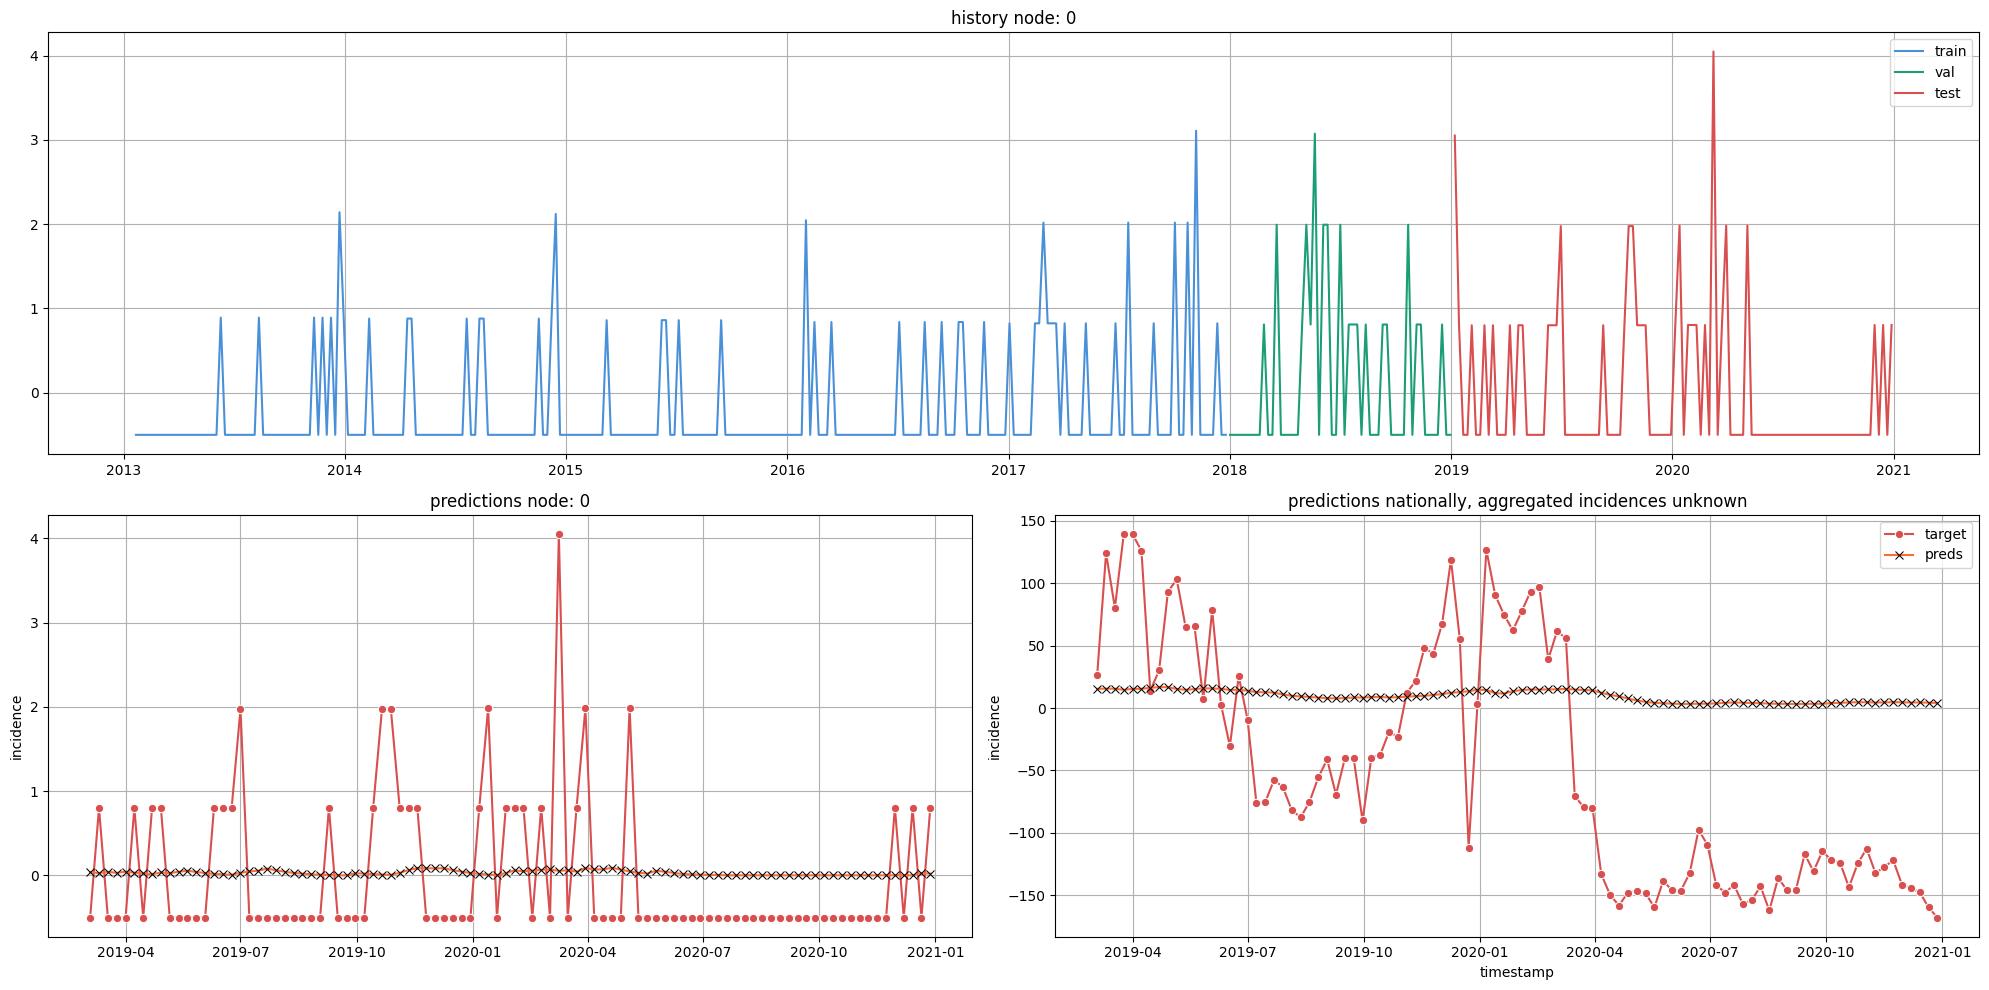

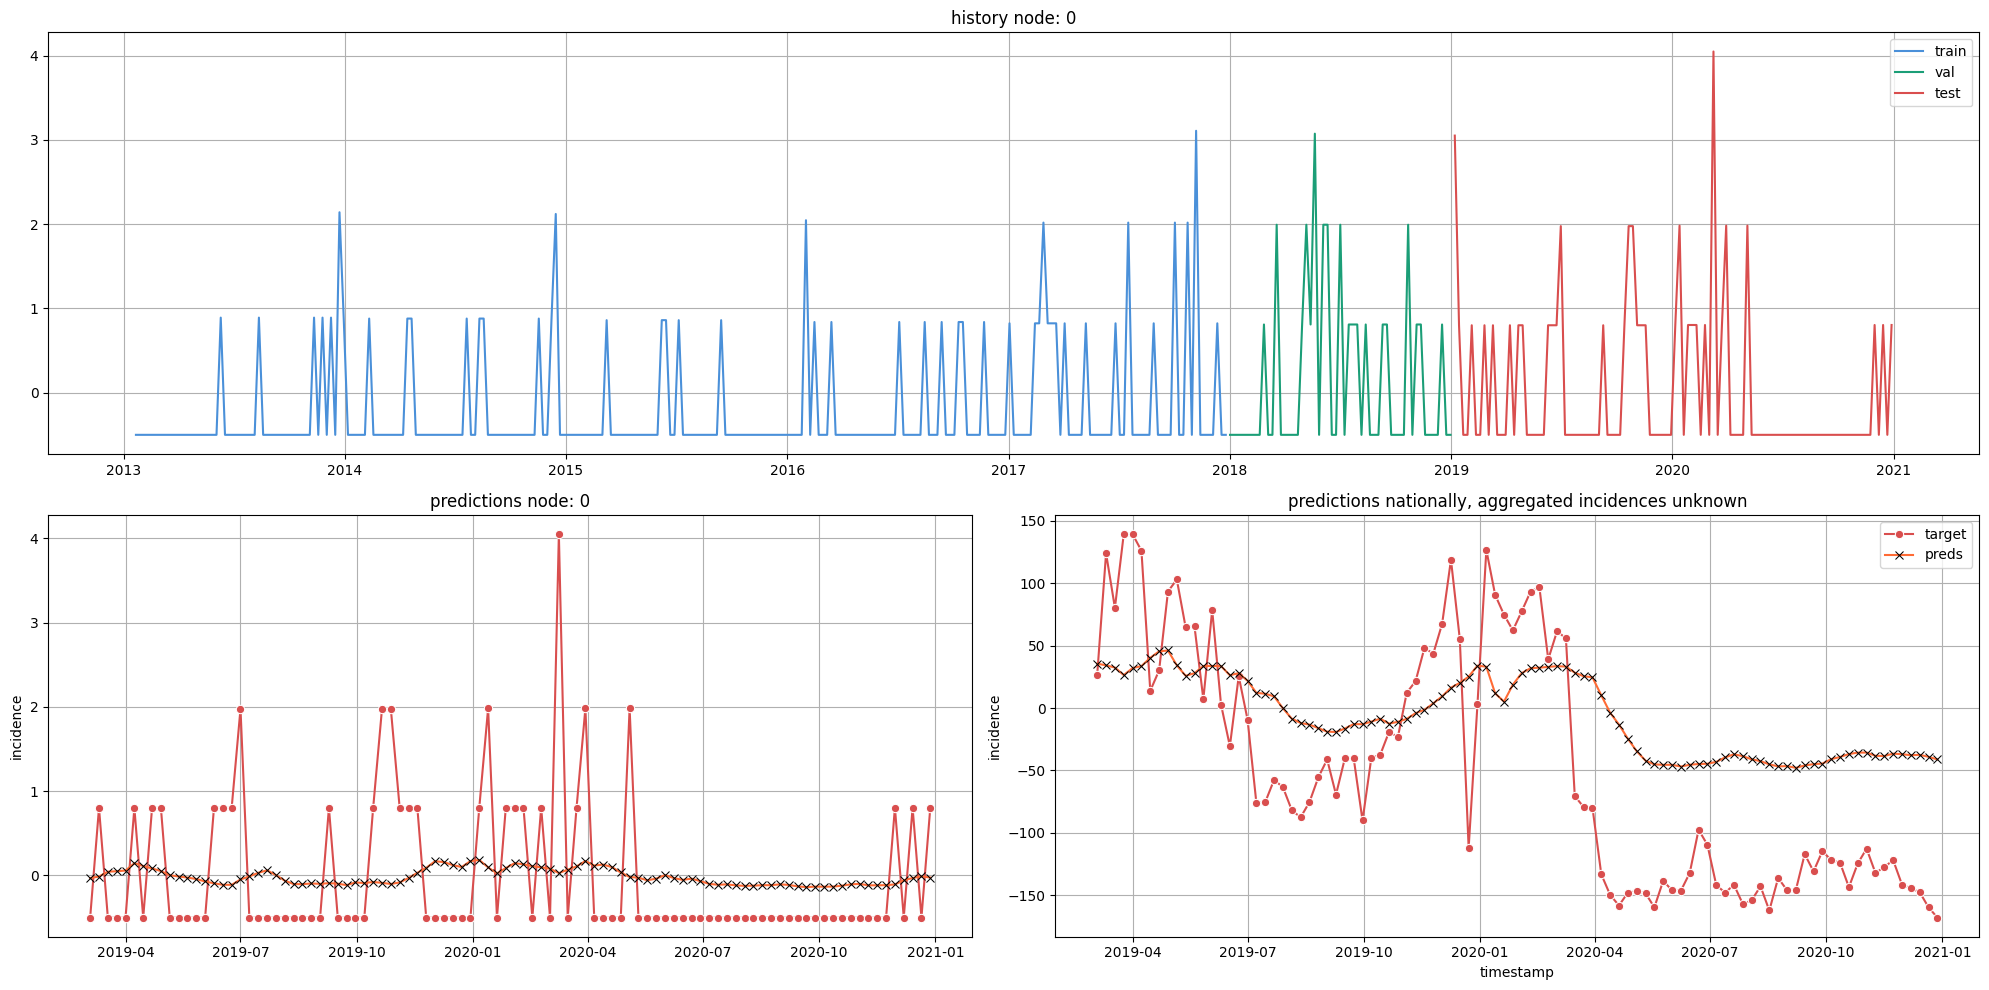

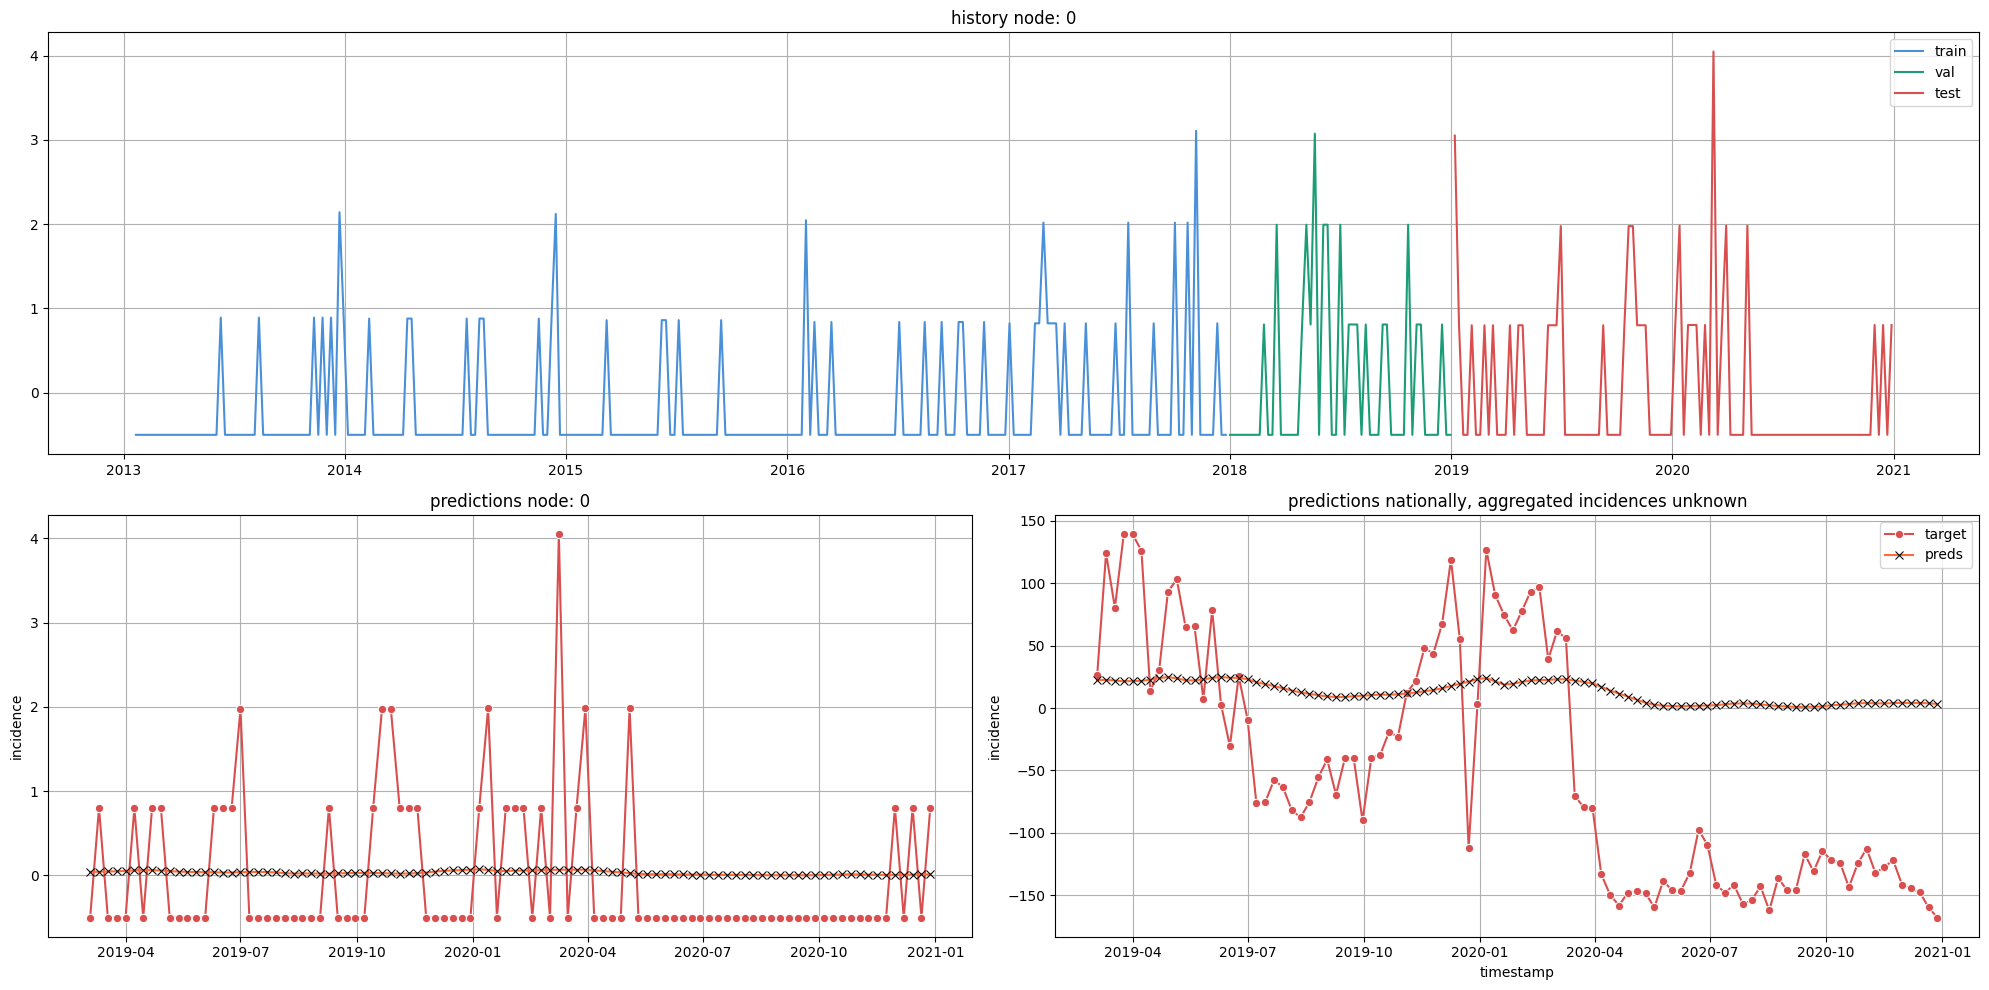

In [28]:
if 'population_size' in epidata.feature_columns:
    epidata.feature_columns.remove('population_size')

gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
# gnnloader1.preview_dataloader(1, timepoint = 10)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)


lr = 0.0001/10

ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader1)
ml.set_model_hparams()
ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)

ml = PaperGRU_GATv2_Model_Wrapper(dataloader = gnnloader3)
ml.set_model_hparams()
ml.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train(show_loss = False)
ml.forecast()
ml.forecast()
ml.show_forecasts(norm=True)
validator = GraphUsageValidator(ml)
# validator.run_tests()
validator.test1()
print(validator.logs)